# Continuation of Part 2 notebook 

This notebook explores how we can use LOB data (up to 20 levels) and various ML/deep learning models to predict short term price movements in BTC. Of particular interest:
1. How much predictve power improvement does it give us over instantaneous order book imbalance? 
2. How can we conver the decision model to a trading strategy 

Please seee Part 2 notebook for further details.

In [444]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

%matplotlib inline 


import lakeapi
import datetime as dt
from datetime import timedelta, datetime, date, time
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import plotly.graph_objects as go 
import mplfinance as mpf
from scipy.stats import pearsonr
from itertools import product

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100)

from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

#my functions 
from helpers import make_features
from train import walk_forward_validate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
raw_df = pd.read_parquet("data/crypto_book_10s_data.parquet")
df, FEAS_LIST = make_features(raw_df)

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /helpers.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)
/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /helpers.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'fwd_ret_{horizon}']= df['mid'].pct_change(horizon).shift(-horizon)
/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /helpers.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future

In [ ]:
#global variables 

PARAMS = {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
}

TRAIN_TEST_SPLIT_PARAMS = {
    'num_splits': 10, 
    'split_ratio': 0.8, 
}

TARGET = 'fwd_ret_3'

QR_PARAMS = {
    'alpha': 1.0,
}
BASIS_POINTS_CONVERSION = 10_000


## Design 

Since short term return has highest correlation with OBI, we limit our analysis to building order flow prediction for forward return 3 periods ahead. 

# Initial Iteration - Nonlinear modelling 

To make sure our samples are independent, we will do walk forward validation using non-overlapping windows. 
To handle the effect of null values (linear model cannot handle) in this section restrict to train_df. 

Note that we using Quantile regression for our linear model since the objective is to minimise MAE. The advantage of this is that it comes with in built regularisation that is controlled by $\alpha$ parameter.

In [14]:
train_df = df.loc[:'2025-12-19'][FEAS_LIST + [TARGET]].dropna()

In [ ]:
# Decision Tree (Nonlinear OBI)
results_nonlinear_all= walk_forward_validate(train_df, features = FEAS_LIST, model_kwargs=PARAMS, target = TARGET, cv_kwargs = TRAIN_TEST_SPLIT_PARAMS)
results_nonlinear_obi = walk_forward_validate(train_df, features = ['obi'], model_kwargs=PARAMS, target = TARGET, cv_kwargs = TRAIN_TEST_SPLIT_PARAMS)

In [ ]:
#Baseline model - Just predict 0 at all times - baked in degenerate model 
baseline_model = walk_forward_validate(train_df, features = FEAS_LIST, target = TARGET, cv_kwargs= TRAIN_TEST_SPLIT_PARAMS, model_type = 'baseline')

In [ ]:
ALPHA = [0.1, 0.5]
results_linear_obi_by_alpha = {}
for a in ALPHA: 
    qr_params = {'alpha': a}
    results_linear_obi_by_alpha[a] = walk_forward_validate(train_df, features = ['obi'], target = TARGET, cv_kwargs = TRAIN_TEST_SPLIT_PARAMS, model_type= 'quantile', model_kwargs= qr_params)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Note that further use with quantile regression model will require standardisation of features due to use of regularisation. So for now we will just look at an unregularised quantile regression model with one variable. 

In [110]:
train_df['fwd_ret_3'].describe()

count    690900.0000000000
mean         -0.0000009963
std           0.0004942494
min          -0.0336609966
25%          -0.0001994594
50%           0.0000000000
75%           0.0001984052
max           0.0267670313
Name: fwd_ret_3, dtype: float64

In [111]:
qr_params = {'alpha': 0}
results_linear_obi_by_alpha[0] = walk_forward_validate(train_df, features = ['obi'], target = TARGET, cv_kwargs = TRAIN_TEST_SPLIT_PARAMS, model_type= 'quantile', model_kwargs= qr_params)

  0%|          | 0/10 [00:00<?, ?it/s]

In [115]:
results_linear_obi_by_alpha[0]['models'][0].coef_

array([4.26355513e-05])

<Axes: >

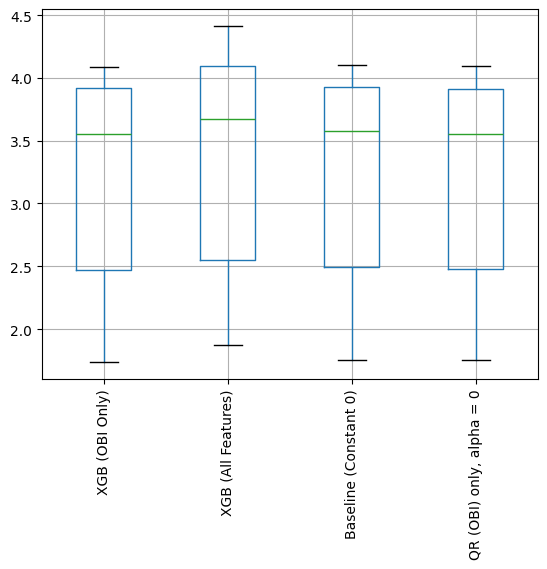

In [113]:
results = pd.DataFrame({
    'XGB (OBI Only)': results_nonlinear_obi['val_scores'], 
    'XGB (All Features)': results_nonlinear_all['val_scores'], 
    'Baseline (Constant 0)': baseline_model['val_scores'], 
    'QR (OBI) only, alpha = 0': results_linear_obi_by_alpha[0]['val_scores'], 
})
results.boxplot(rot = 90)

In [114]:
results.median()

XGB (OBI Only)              3.5529484304
XGB (All Features)          3.6717068214
Baseline (Constant 0)       3.5781100182
QR (OBI) only, alpha = 0    3.5494368296
dtype: float64

It is interesting to note that simple quantile regression outperforms the decision tree model.  

# Understand discrepancy between XGB decision tree vs. XGB Quantile Regression? 

1. Learning curves of XGBoost - compared to number of trees 
   1. Do they look alright? 

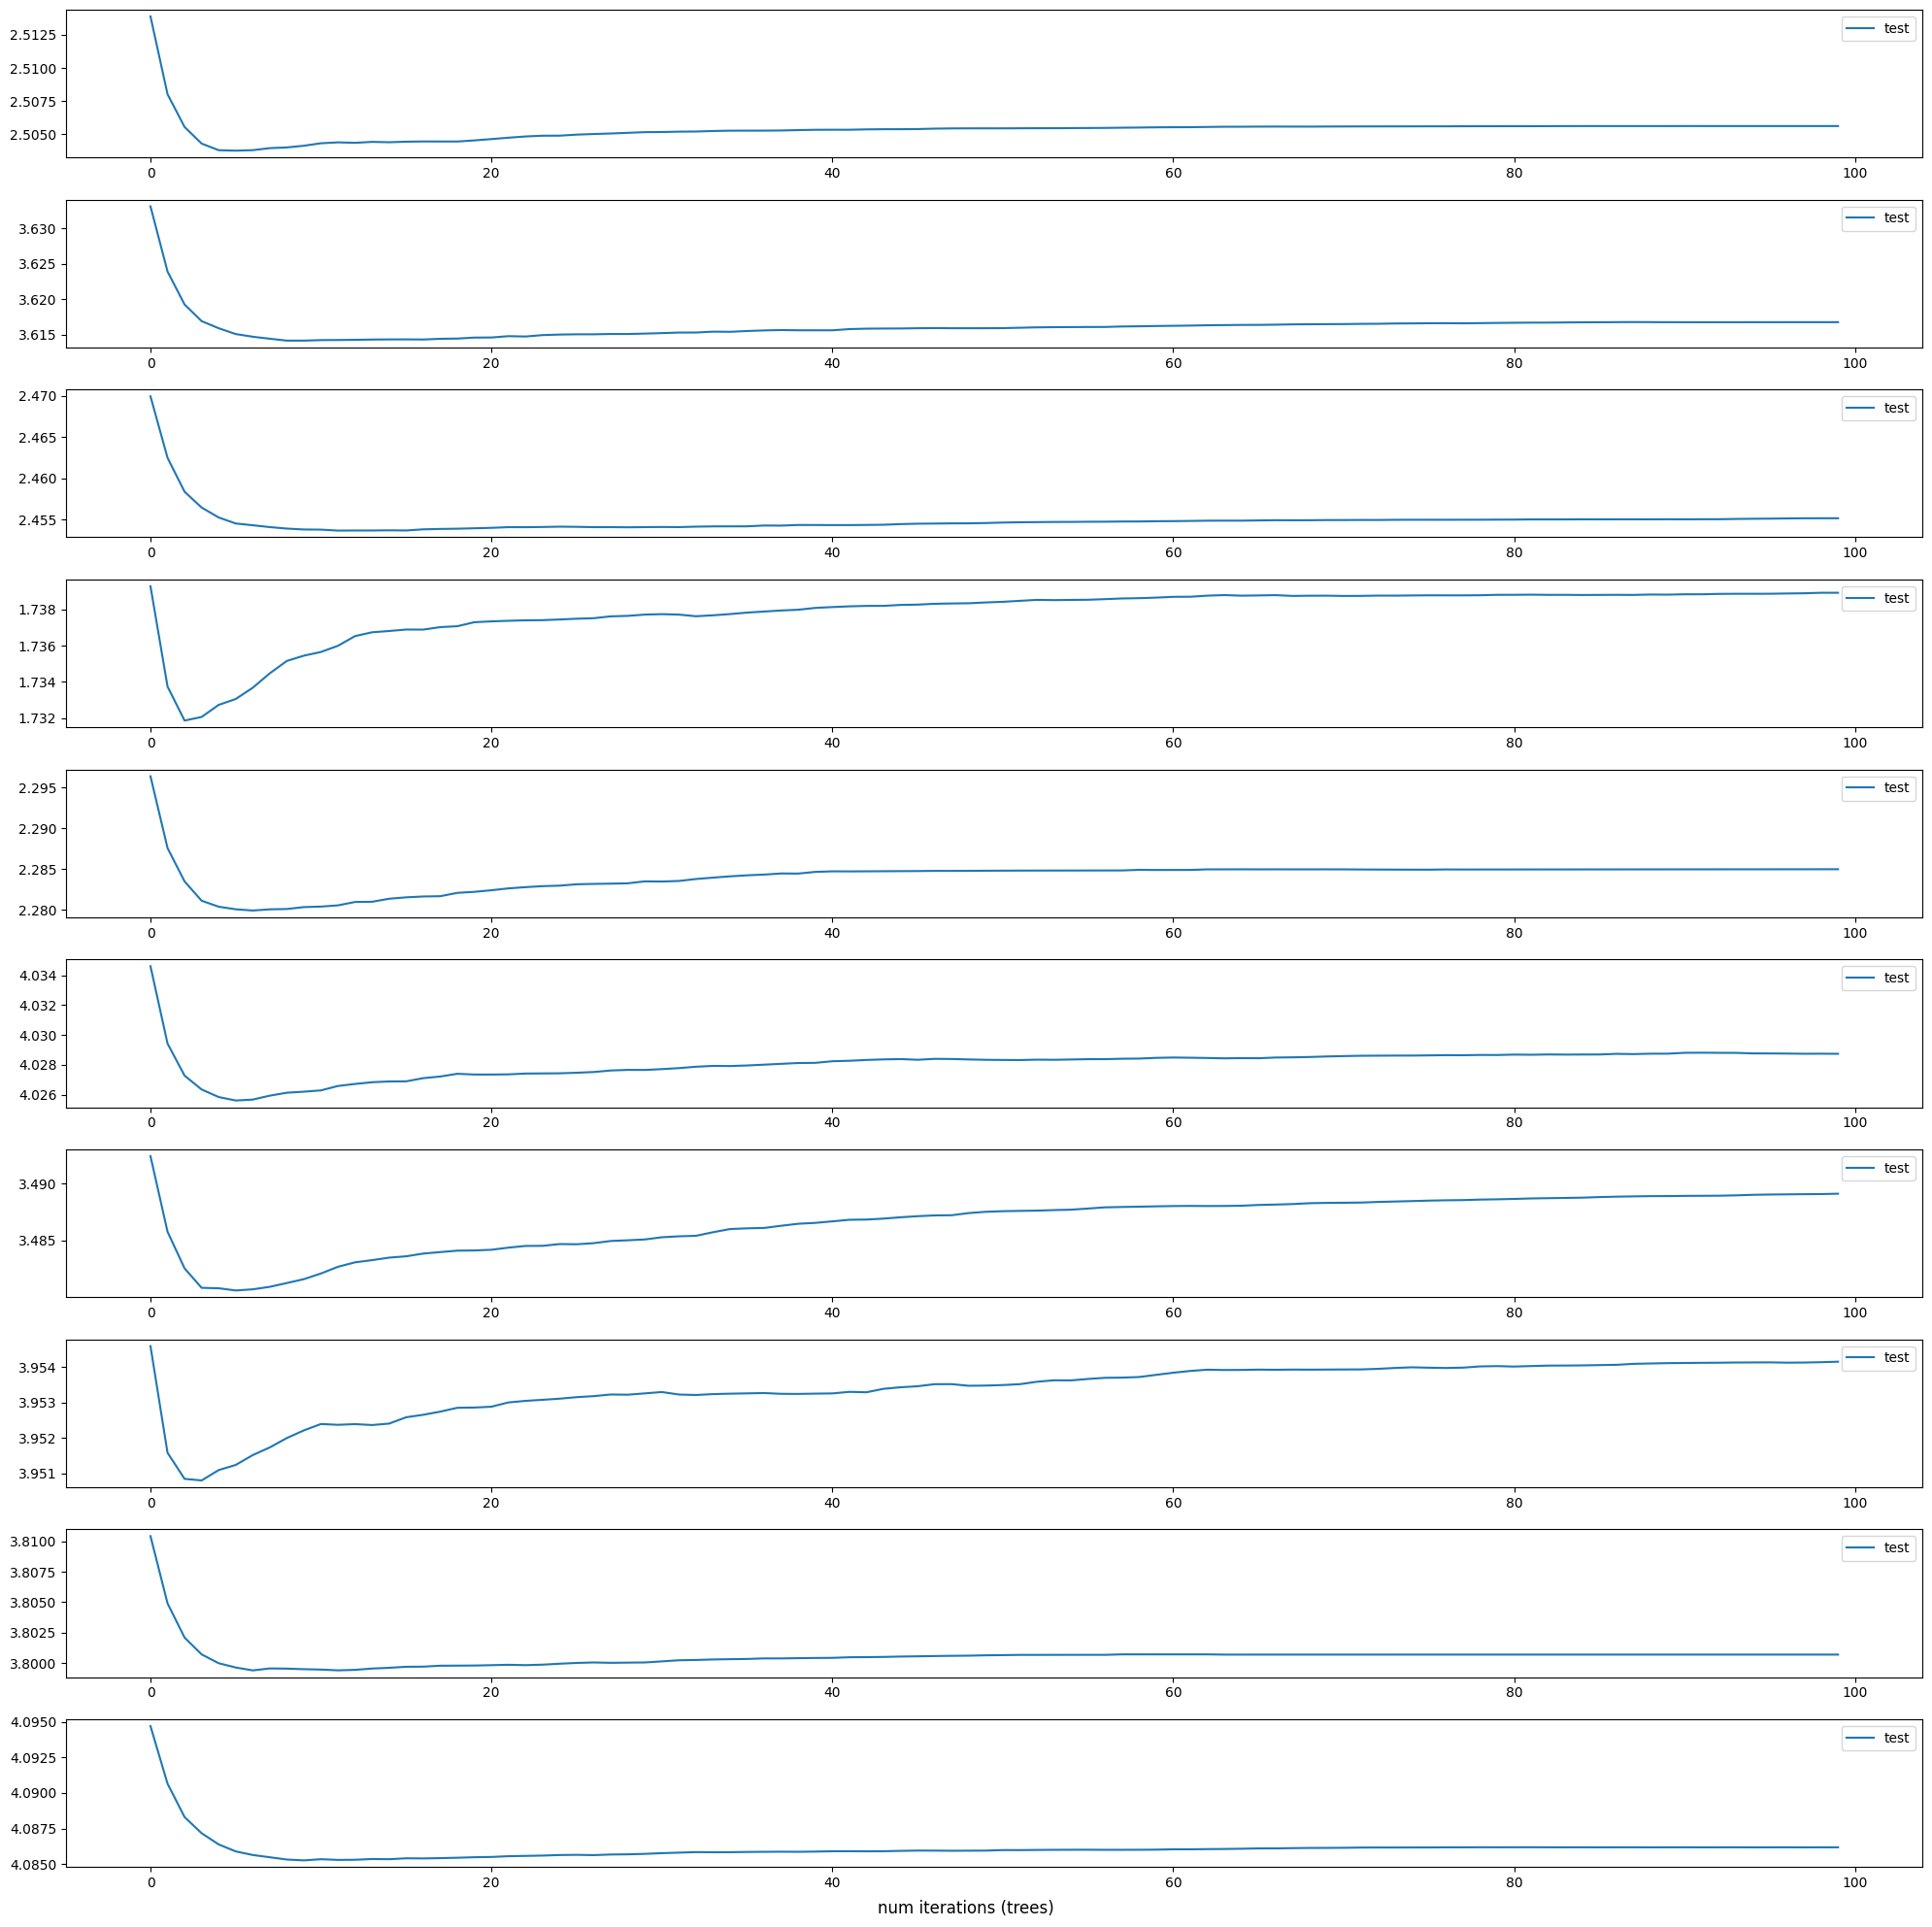

In [144]:
InteractiveShell.ast_node_interactivity = "last_expr"

fig, ax = plt.subplots(nrows = len(results_nonlinear_obi['models']), figsize = (20, 20));
for m, a in zip(results_nonlinear_obi['models'], ax): 
    scores= m.evals_result()
    train = [s*BASIS_POINTS_CONVERSION for s in scores['validation_0']['mae']]
    test = [s*BASIS_POINTS_CONVERSION for s in scores['validation_1']['mae']]
    #a.plot(train, label = 'train');
    a.plot(test, label = 'test');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

In [ ]:
#Why is the XGB decision tree performing so poorly? 
#Clearly some easy/immediate steps to fix up, since it should at least outperform the dummy/unintelligent baseline

In [187]:
params= {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
    'early_stopping_rounds': 10
}

results_nonlinear_obi_early_stopping = walk_forward_validate(train_df, features = ['obi'], model_kwargs=params, target = TARGET, cv_kwargs = TRAIN_TEST_SPLIT_PARAMS)

  0%|          | 0/10 [00:00<?, ?it/s]

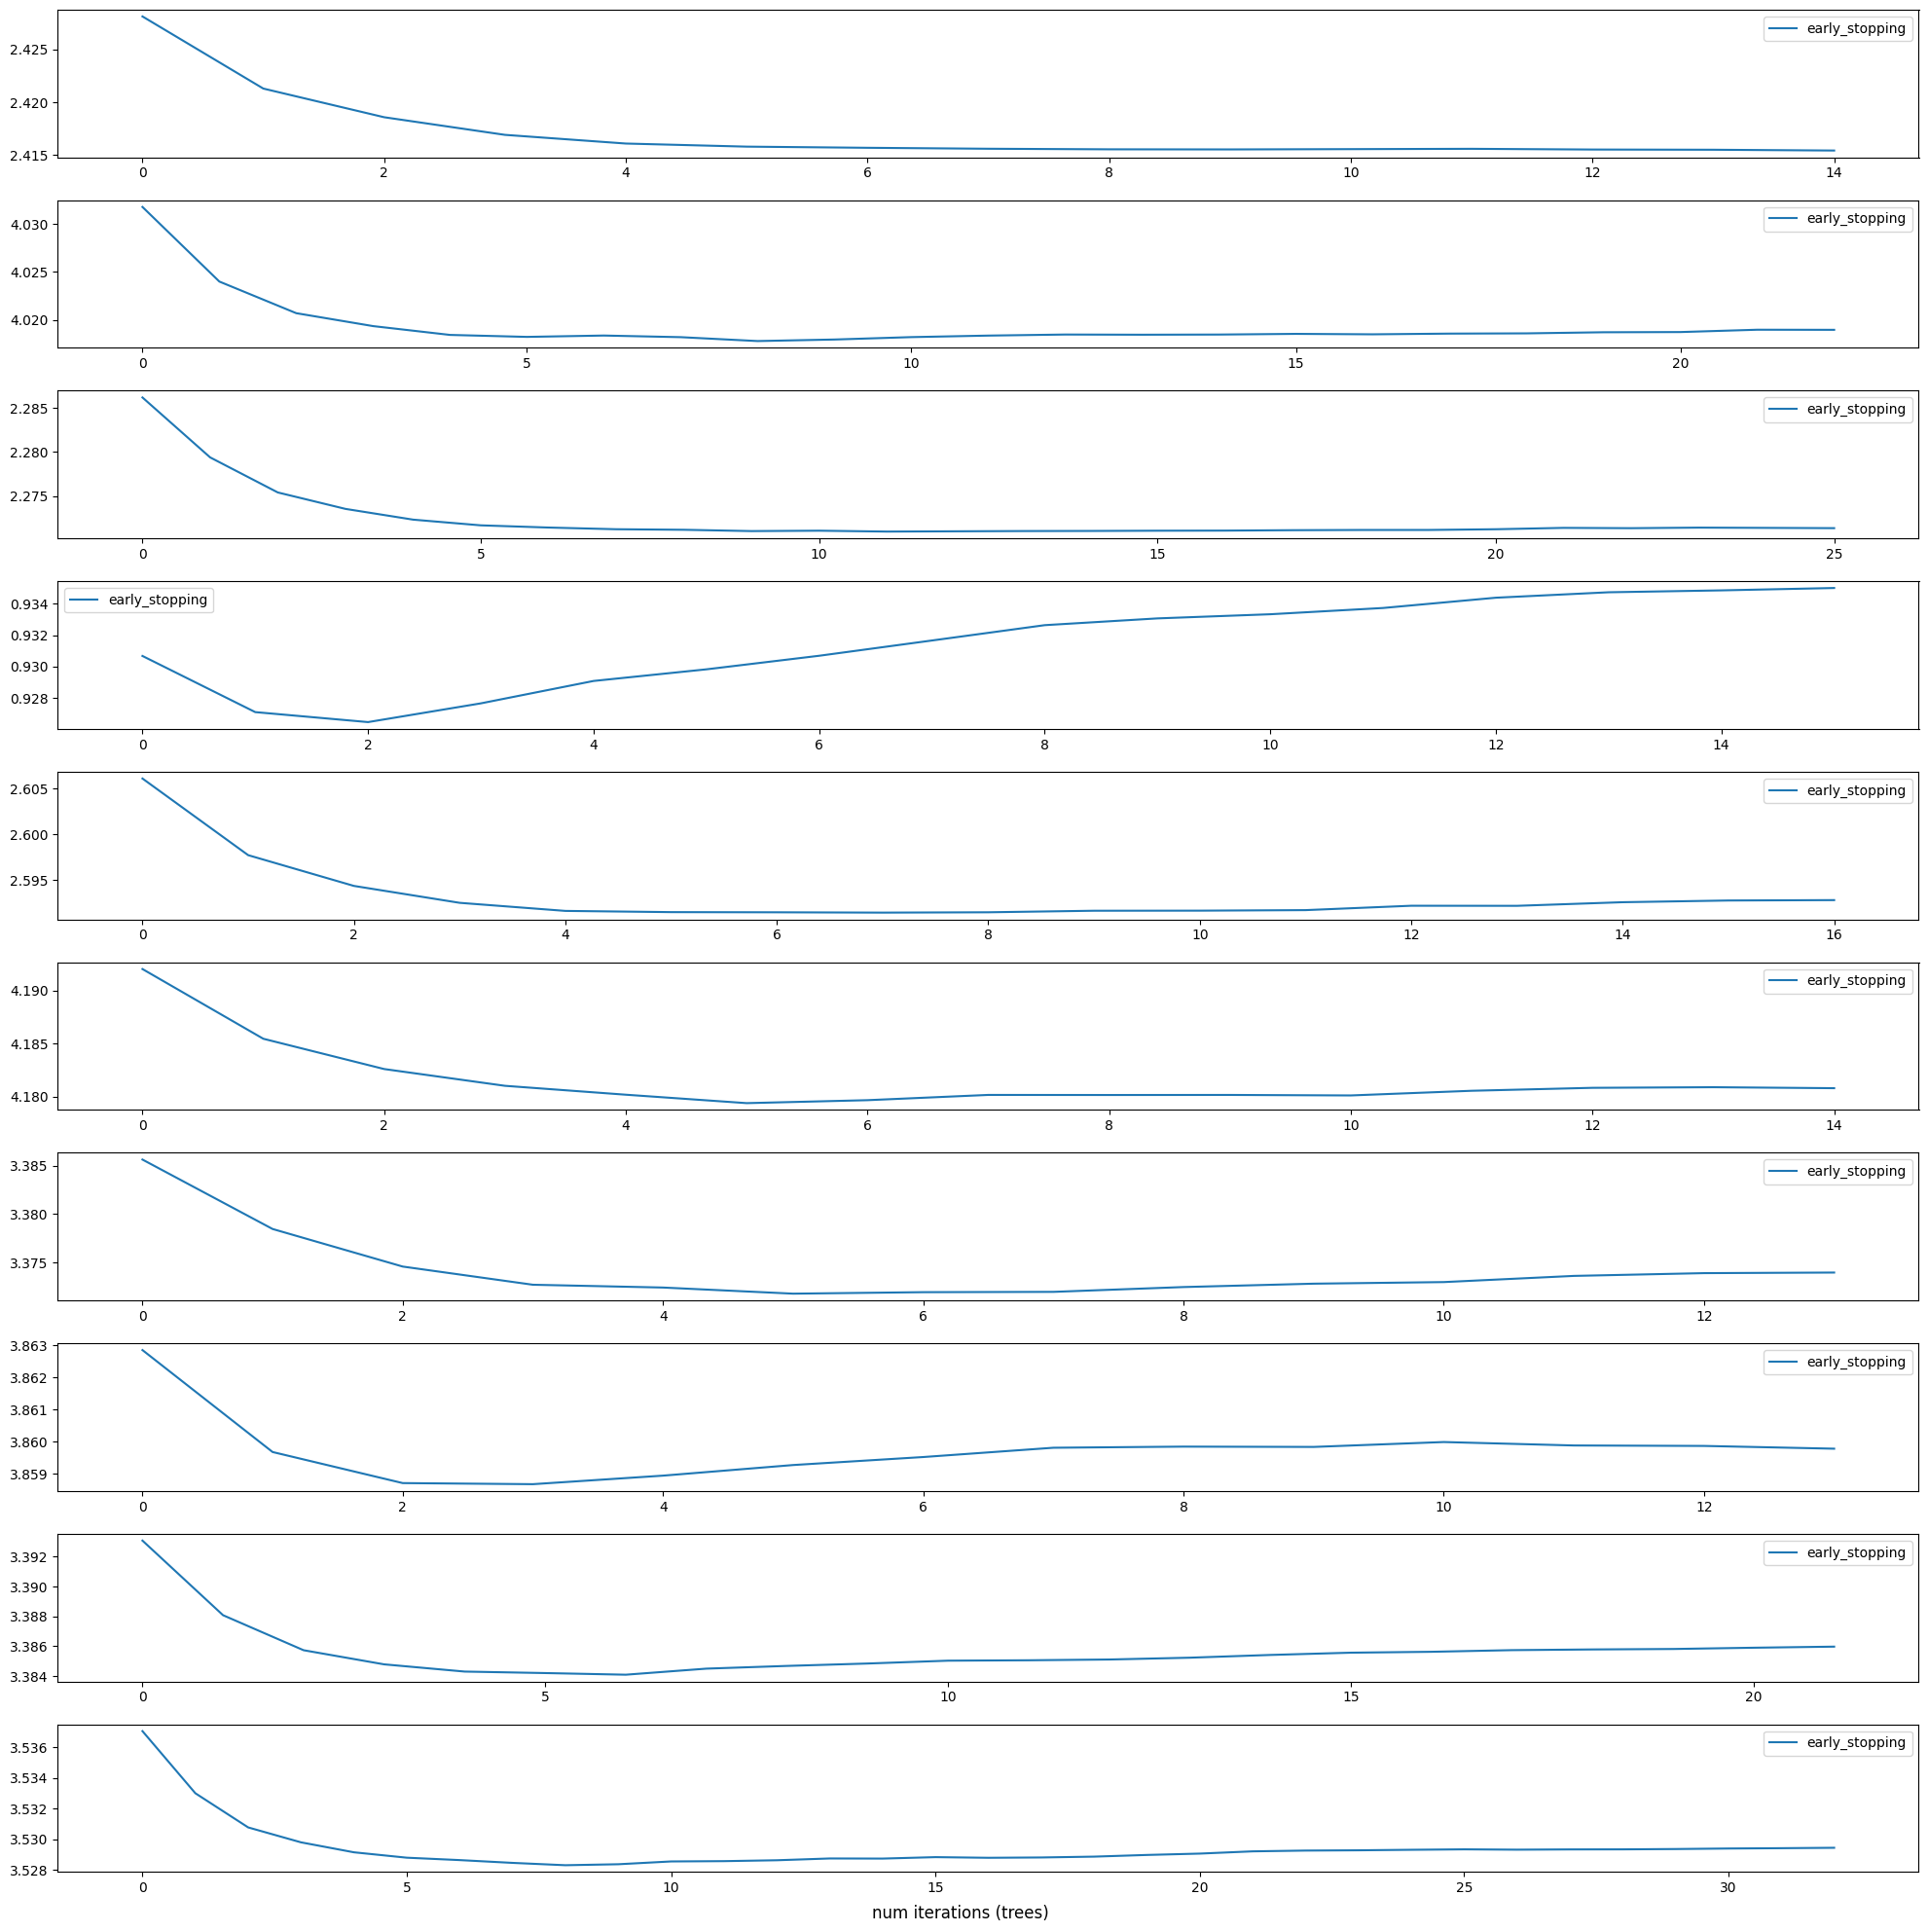

In [191]:
InteractiveShell.ast_node_interactivity = "last_expr"

fig, ax = plt.subplots(nrows = len(results_nonlinear_obi_early_stopping['models']), figsize = (20, 20));
for m, a in zip(results_nonlinear_obi_early_stopping['models'], ax): 
    scores= m.evals_result()
    train = [s*BASIS_POINTS_CONVERSION for s in scores['validation_0']['mae']]
    test = [s*BASIS_POINTS_CONVERSION for s in scores['validation_1']['mae']]
    early_stopping = [s*BASIS_POINTS_CONVERSION for s in scores['validation_2']['mae']]
    #a.plot(train, label = 'train');
    #a.plot(test, label = 'test');
    a.plot(test, label = 'early_stopping');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

<Axes: >

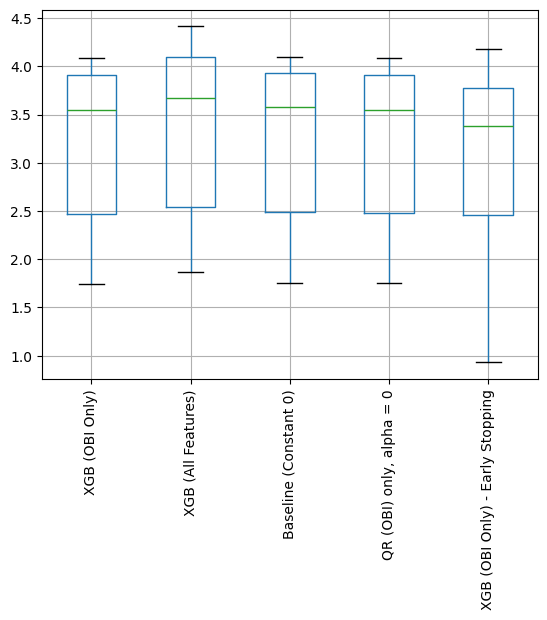

In [189]:
results = pd.DataFrame({
    'XGB (OBI Only)': results_nonlinear_obi['val_scores'], 
    'XGB (All Features)': results_nonlinear_all['val_scores'], 
    'Baseline (Constant 0)': baseline_model['val_scores'], 
    'QR (OBI) only, alpha = 0': results_linear_obi_by_alpha[0]['val_scores'], 
    'XGB (OBI Only) - Early Stopping': results_nonlinear_obi_early_stopping['val_scores'],
})
results.boxplot(rot = 90)

In [190]:
results.median()

XGB (OBI Only)                     3.5529484304
XGB (All Features)                 3.6717068214
Baseline (Constant 0)              3.5781100182
QR (OBI) only, alpha = 0           3.5494368296
XGB (OBI Only) - Early Stopping    3.3788755801
dtype: float64

Note that XGB with OBI delivers good improvement gains when we implement early stopping. 

Note that XGB with early stopping may have slightly biased results since we USED the validation data to inform us that early stopping may be nedded, and approximately how many early stopping rounds are required. However, note that we split up the validation data into early stopping and validation data to minimse data leakage as much as possible. Nonetheless, should take results with a grain of salt. 

Note that we are still getting incidences of MAE error increasing after a very early number of iterations (like 1-3), so some residual overfitting concern. 

In [242]:
# Other Debug Steps - All Features 

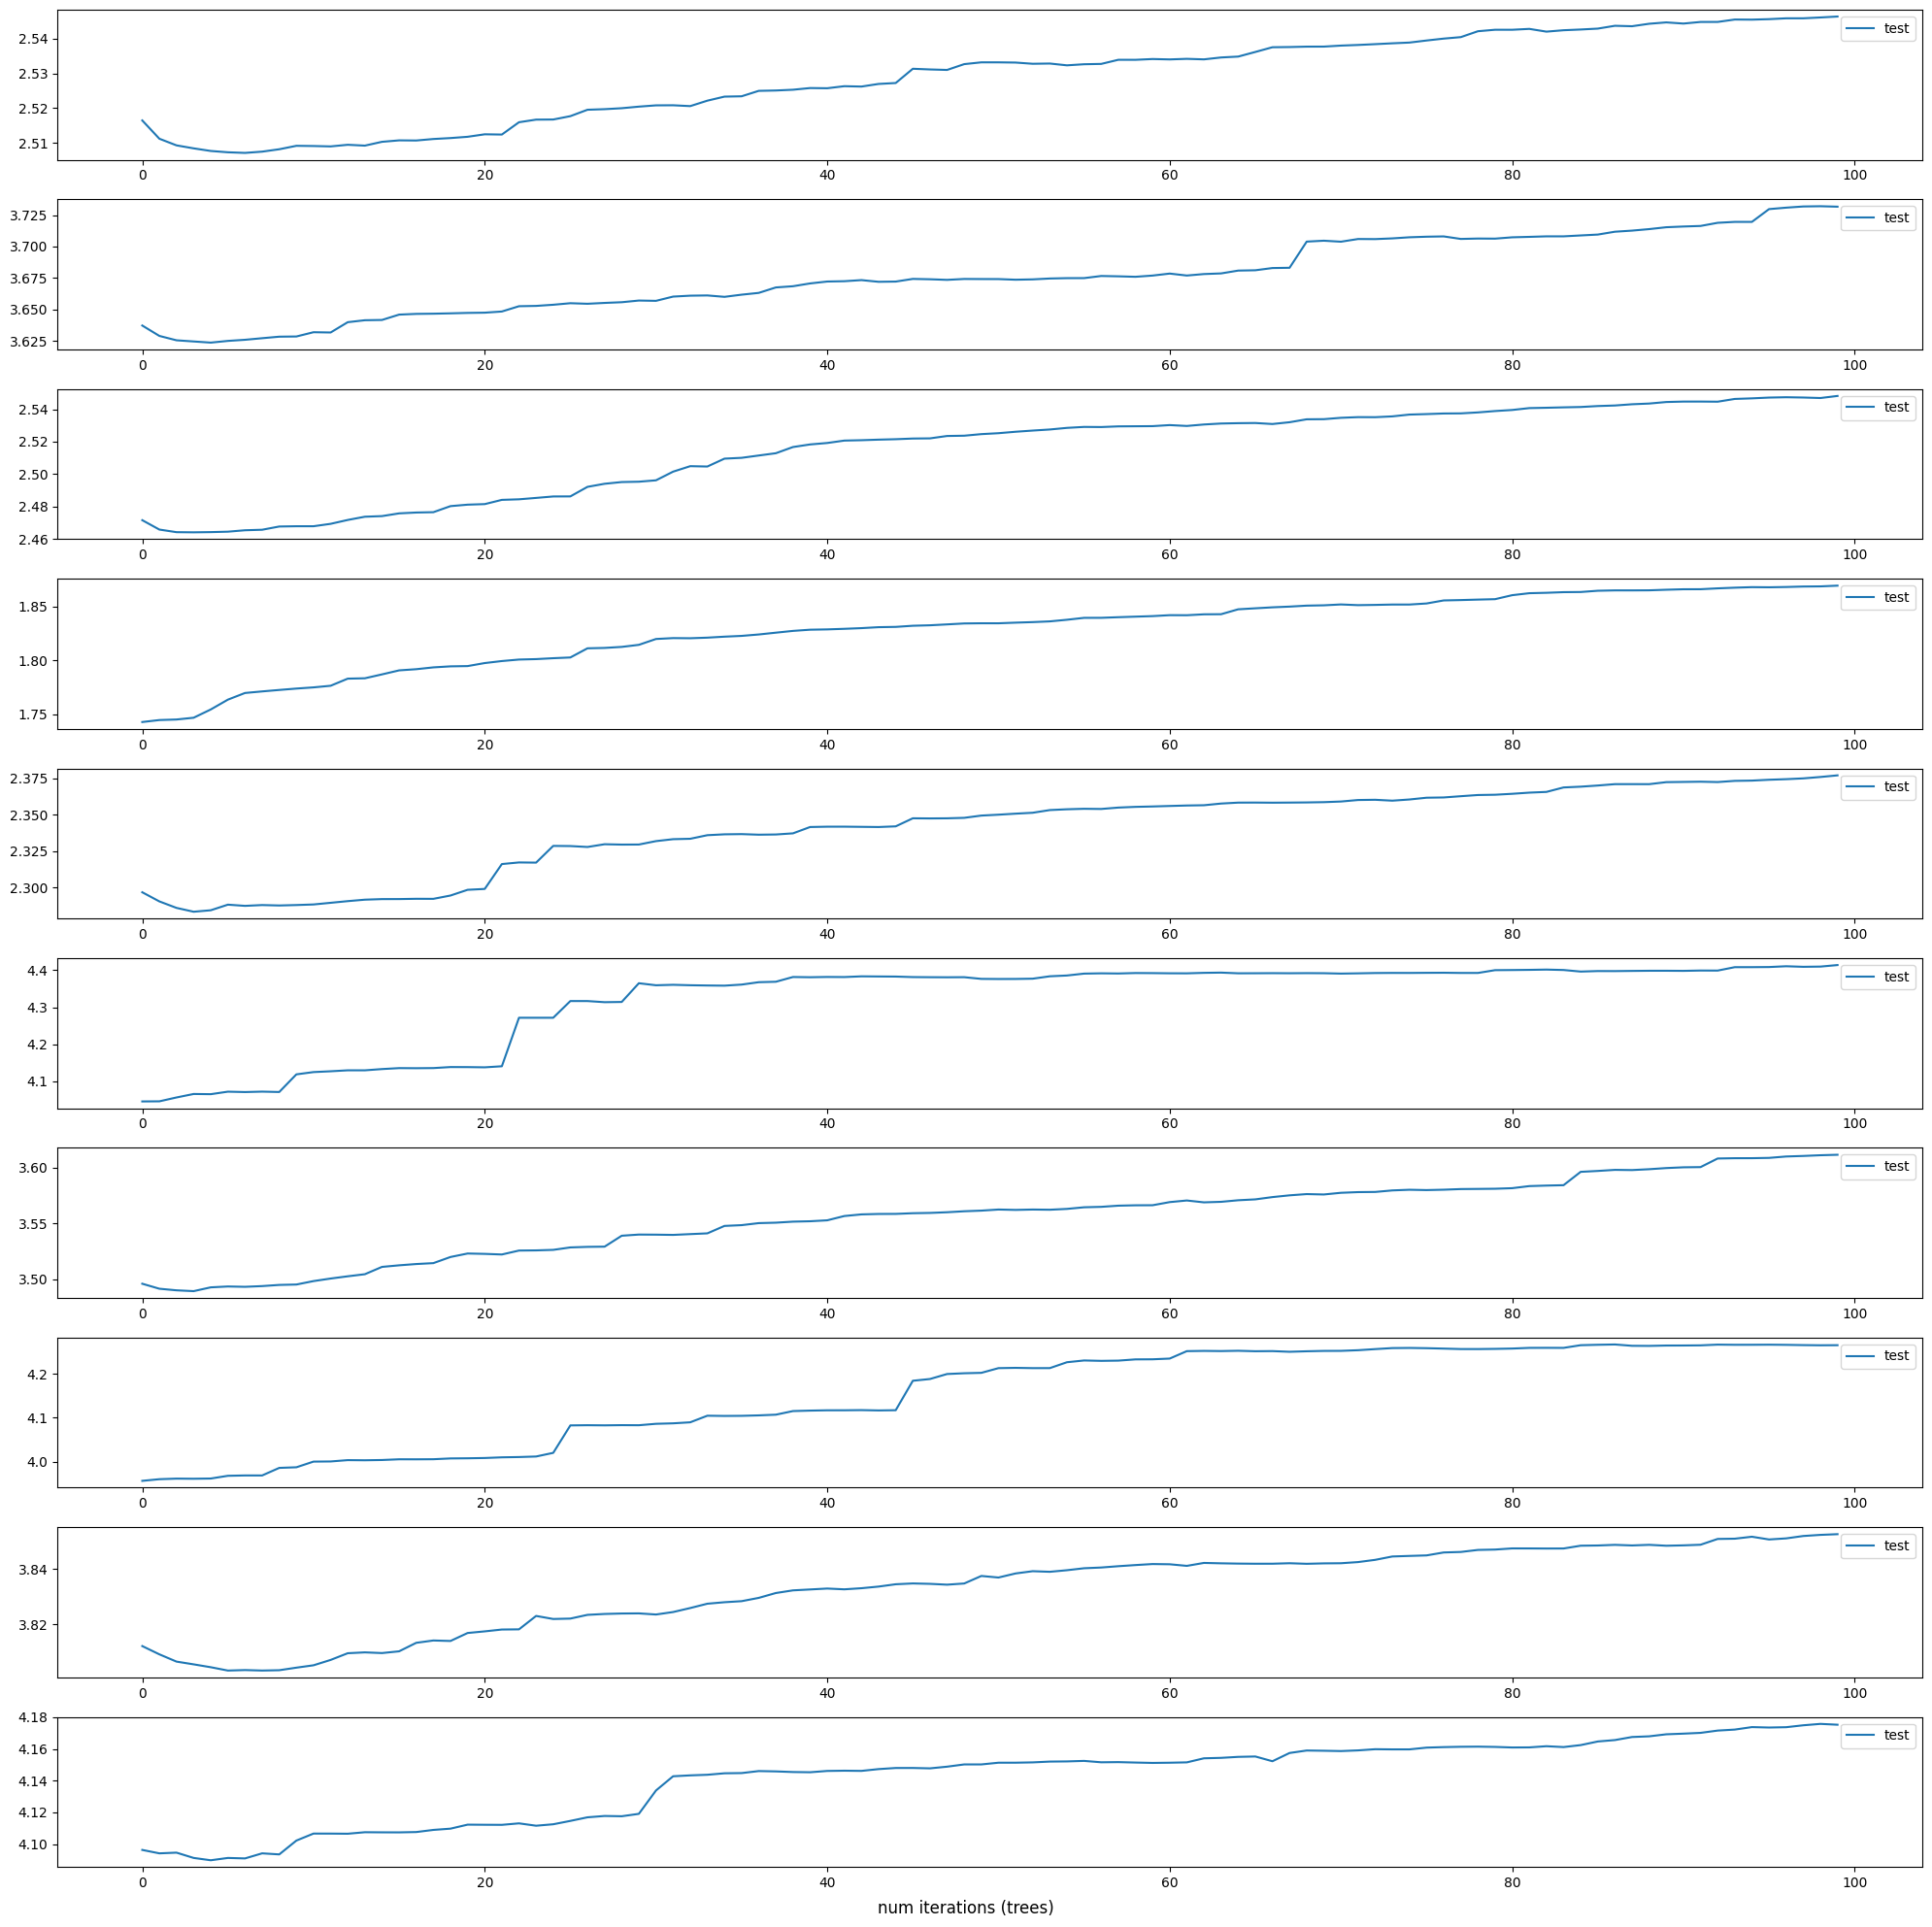

In [ ]:
InteractiveShell.ast_node_interactivity = "last_expr"

fig, ax = plt.subplots(nrows = len(results_nonlinear_all['models']), figsize = (20, 20));
for m, a in zip(results_nonlinear_all['models'], ax): 
    scores= m.evals_result()
    train = [s*BASIS_POINTS_CONVERSION for s in scores['validation_0']['mae']]
    test = [s*BASIS_POINTS_CONVERSION for s in scores['validation_1']['mae']]
    #early_stopping = [s*BASIS_POINTS_CONVERSION for s in scores['validation_2']['mae']]
    #a.plot(train, label = 'train');
    a.plot(test, label = 'test');
    #a.plot(test, label = 'early_stopping');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

The test error is increasing almost immediately, suggesting we have initial overfitting. So the tree is too complex.

In [218]:
params= {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
    'max_depth': 3,
}

results_nonlinear_all_tree_depth = walk_forward_validate(train_df, features = FEAS_LIST, model_kwargs=params, target = TARGET, cv_kwargs = {'num_splits': 10})

  0%|          | 0/10 [00:00<?, ?it/s]

In [223]:
results_nonlinear_all_tree_depth['val_mean']

np.float64(3.1407209861862606)

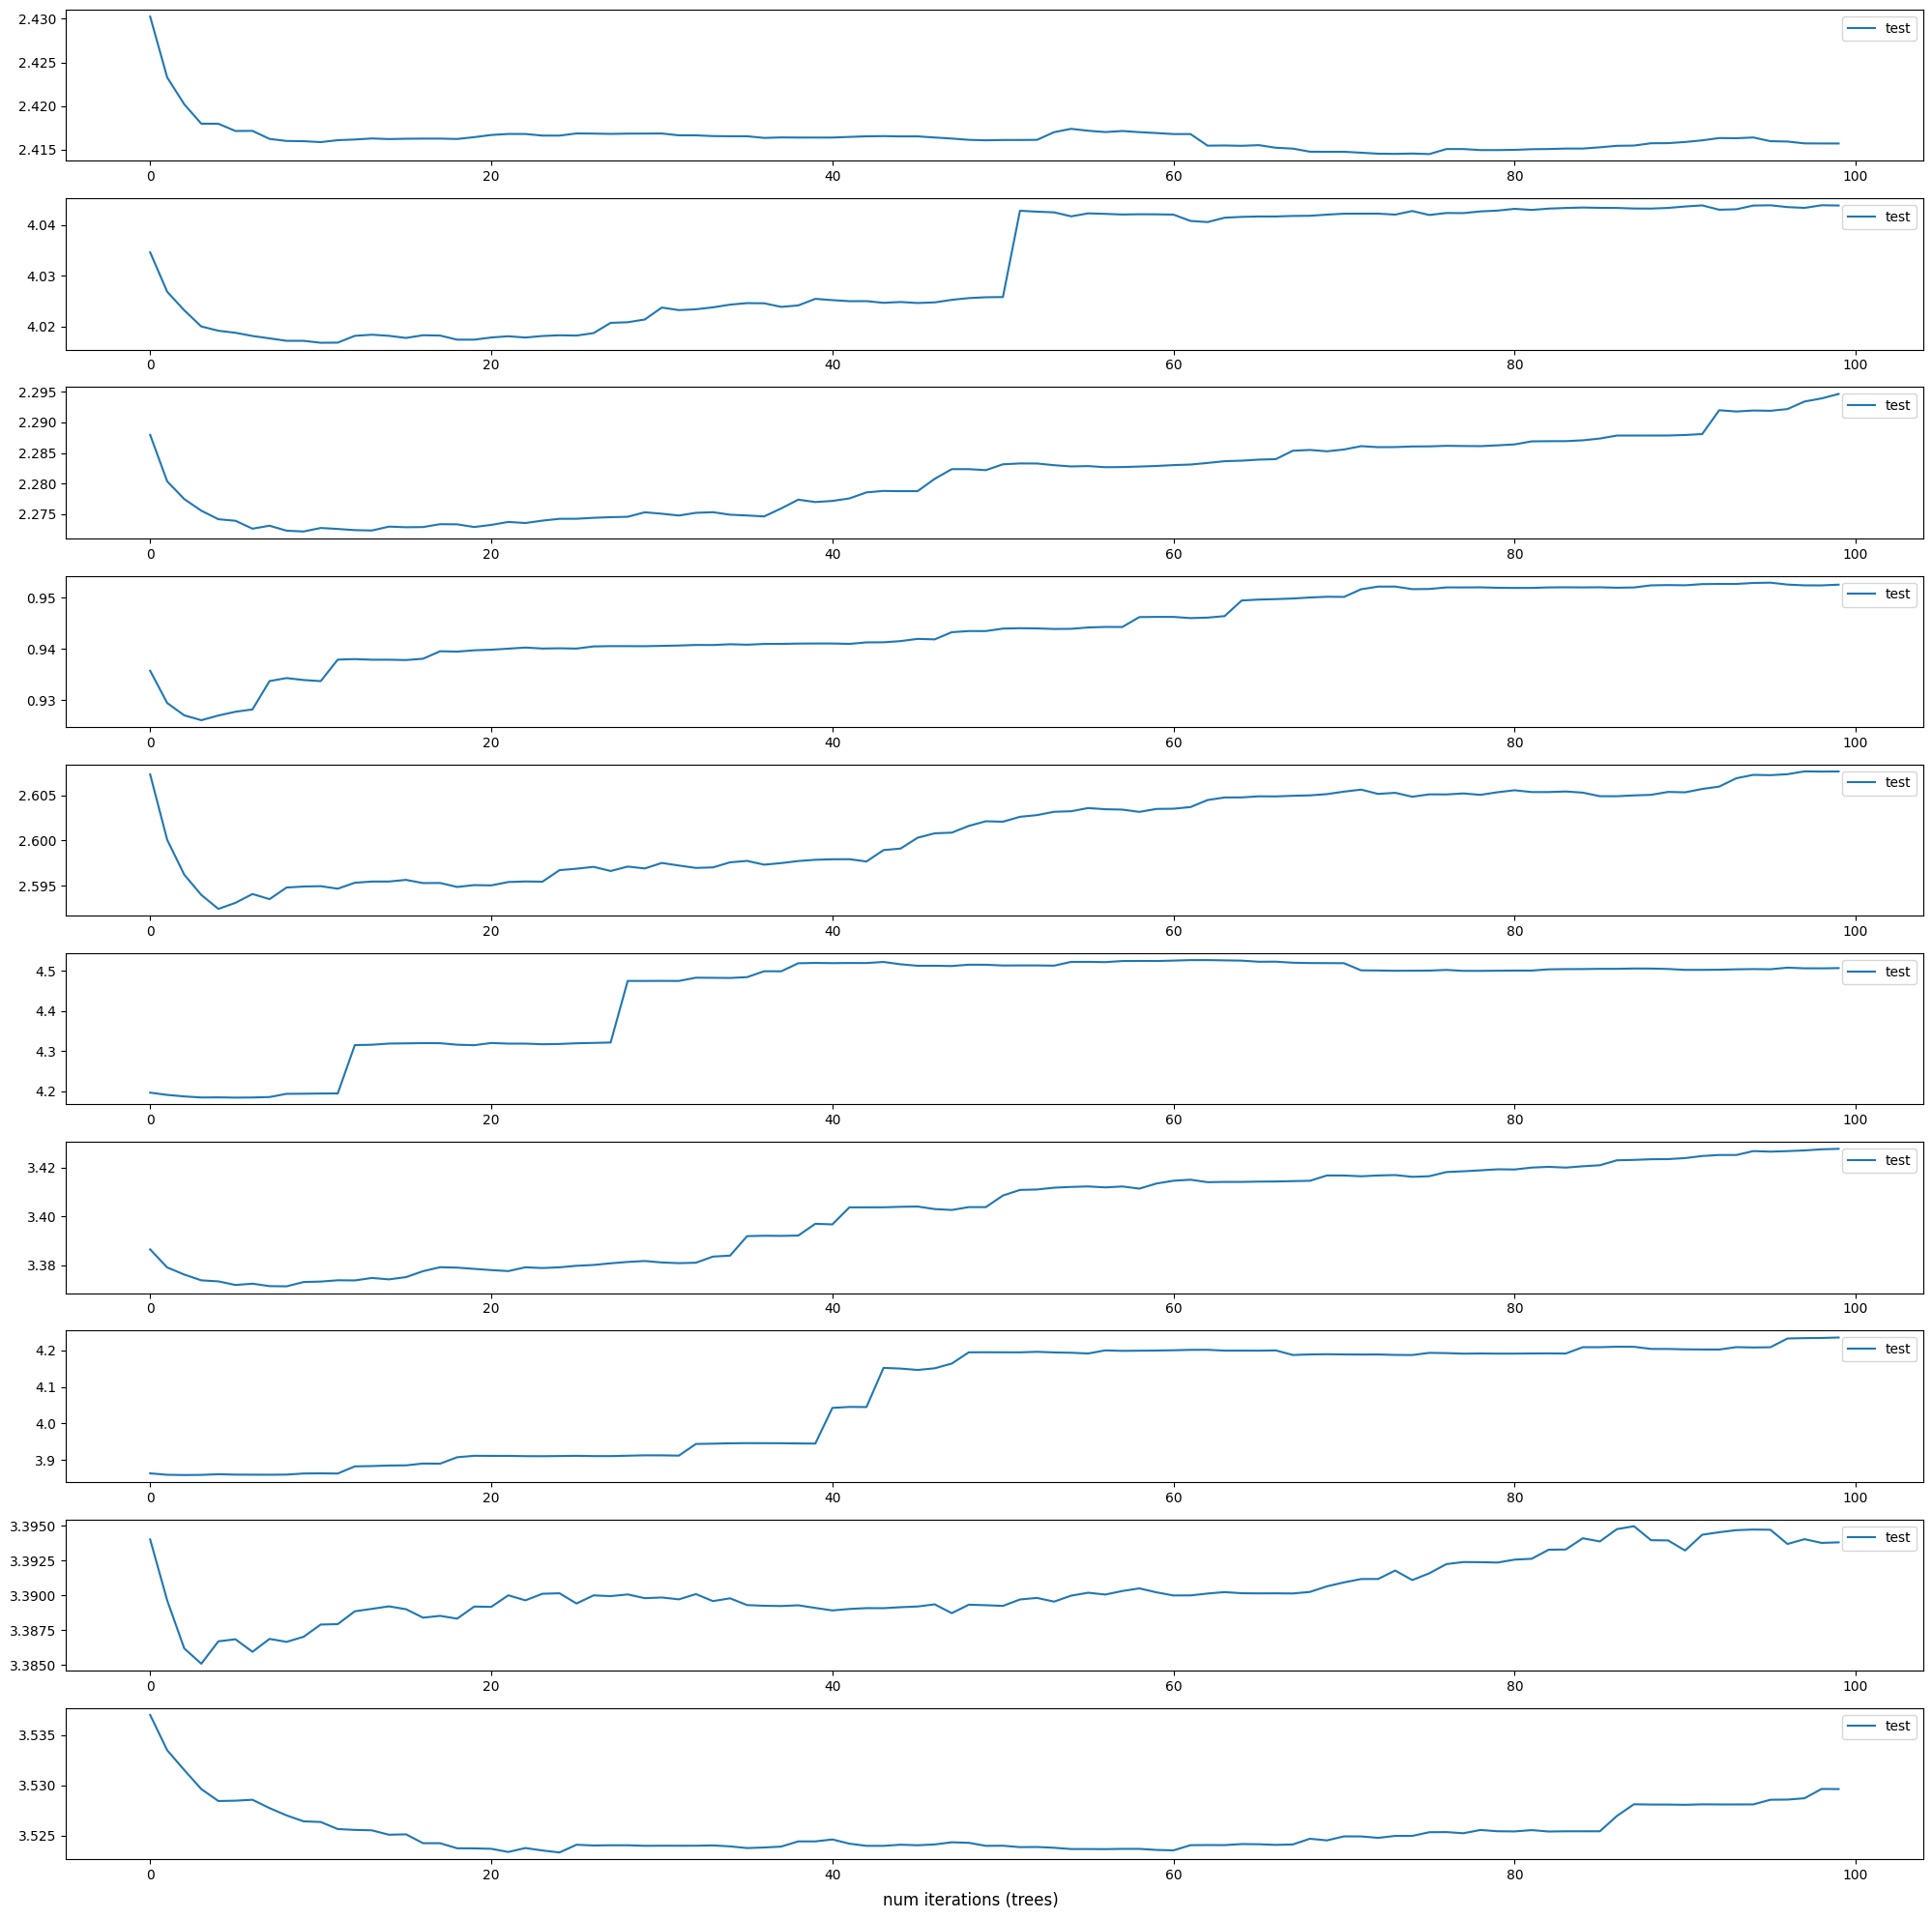

In [243]:
InteractiveShell.ast_node_interactivity = "last_expr"

fig, ax = plt.subplots(nrows = len(results_nonlinear_all_tree_depth['models']), figsize = (20, 20));
for m, a in zip(results_nonlinear_all_tree_depth['models'], ax): 
    scores= m.evals_result()
    train = [s*BASIS_POINTS_CONVERSION for s in scores['validation_0']['mae']]
    test = [s*BASIS_POINTS_CONVERSION for s in scores['validation_1']['mae']]
    #early_stopping = [s*BASIS_POINTS_CONVERSION for s in scores['validation_2']['mae']]
    #a.plot(train, label = 'train');
    a.plot(test, label = 'test');
    #a.plot(test, label = 'early_stopping');
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

In [434]:
#increase eta rate 

params= {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
    'max_depth': 3,
    'learning_rate': 0.05, #decrease the learning rate 
    'n_estimators': 100,
    'subsample': 0.75,
    'early_stopping_rounds': 20,
    'n_estimators': 200,
}

results = walk_forward_validate(train_df, features = FEAS_LIST, model_kwargs=params, target = TARGET, cv_kwargs = {'num_splits': 10})

  0%|          | 0/10 [00:00<?, ?it/s]

In [435]:
results['val_mean']

np.float64(3.055060458582093)

In [436]:
BASELINE_PERFORMANCE = 3.57

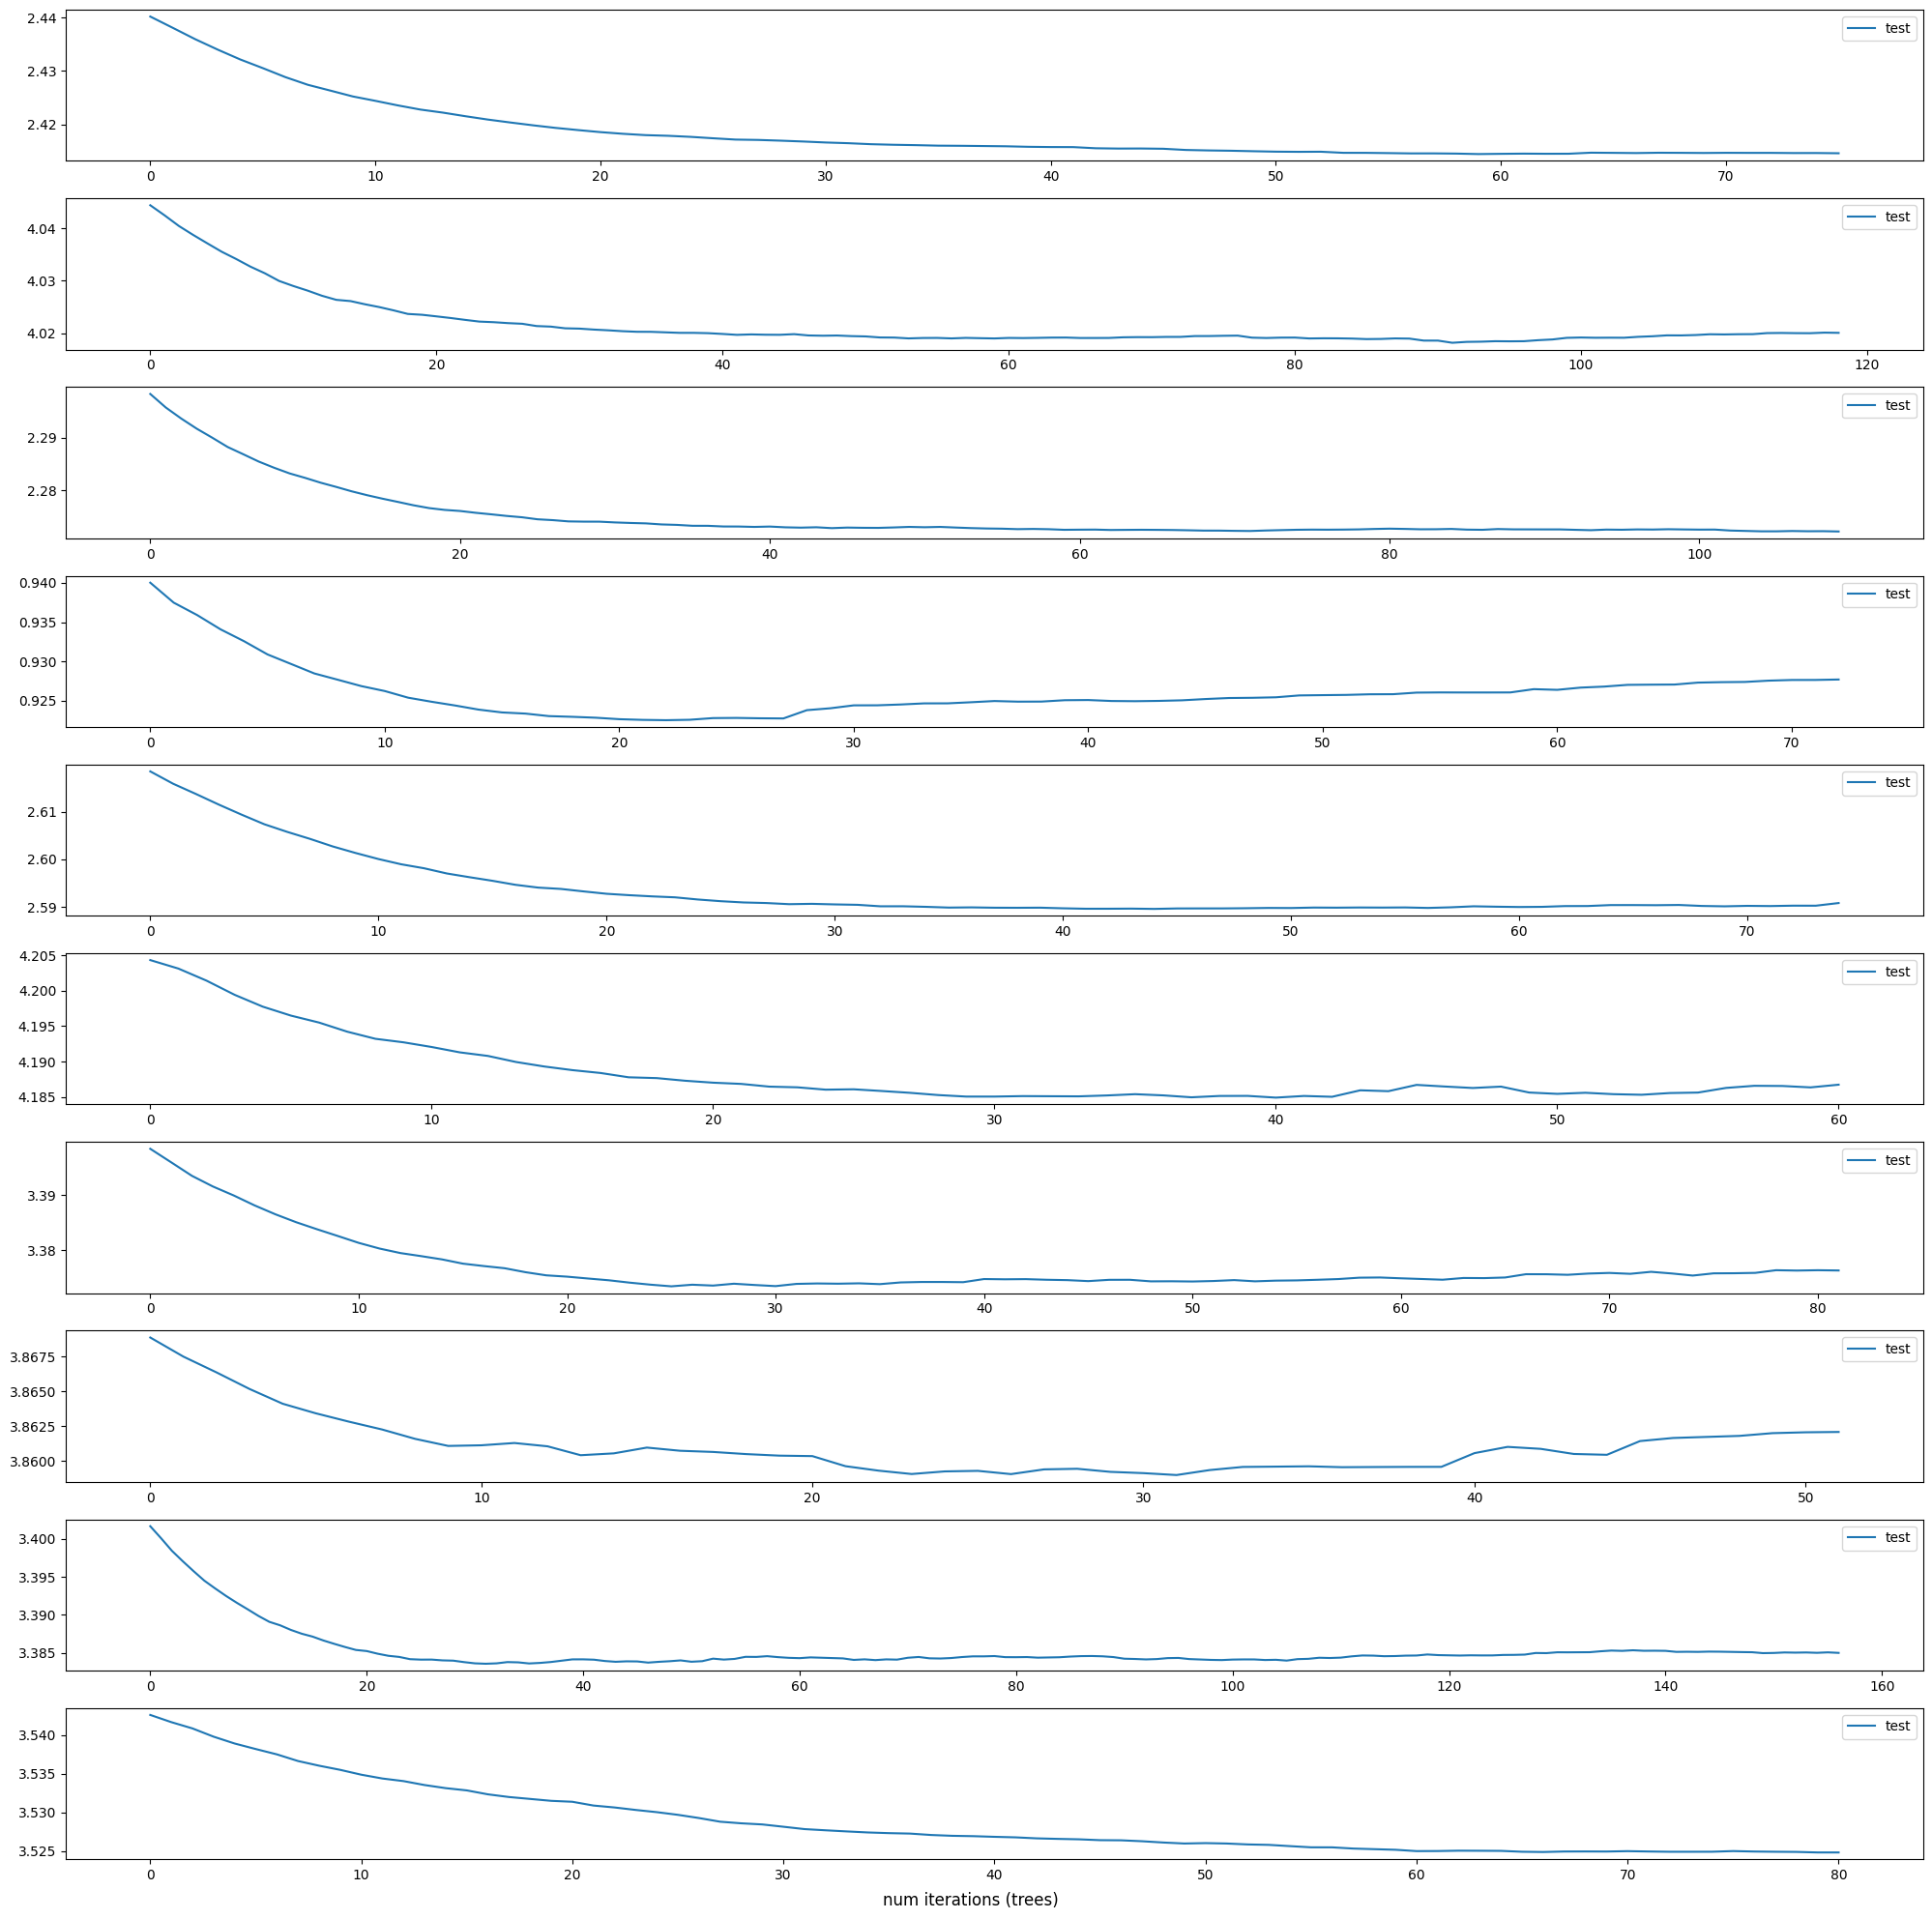

In [438]:
InteractiveShell.ast_node_interactivity = "last_expr"

fig, ax = plt.subplots(nrows = len(results['models']), figsize = (20, 20));
for m, a in zip(results['models'], ax): 
    scores= m.evals_result()
    train = [s*BASIS_POINTS_CONVERSION for s in scores['validation_0']['mae']]
    test = [s*BASIS_POINTS_CONVERSION for s in scores['validation_1']['mae']]
    early_stopping = [s*BASIS_POINTS_CONVERSION for s in scores['validation_2']['mae']]
    #a.plot(train, label = 'train');
    a.plot(test, label = 'test');
    #a.plot(early_stopping, label = 'early_stopping');
    #a.axhline(y = BASELINE_PERFORMANCE, label = 'baseline_performance', color = 'red', linestyle = '--')
    a.legend();
fig.supxlabel("num iterations (trees)")
fig.tight_layout()

# Fold Instability - what are these situations where test data << train data? 

In [ ]:
## Debug - WHY/in what situations do we have that training error < test error? 

# Any glaring, sudden shifts in behaviour? 

In [414]:
from train import train_test_split
tss= train_test_split(data_length = len(train_df), num_splits = 10, split_ratio = 0.8)
fold_train, fold_test = tss[4]
fold_train_df = train_df.iloc[fold_train]
fold_test_df = train_df.iloc[fold_test]

<BarContainer object of 10 artists>

<BarContainer object of 10 artists>

Text(0.5, 0, 'Fold')

Text(0, 0.5, 'MAE (bps)')

Text(0.5, 1.0, 'QR Train vs Val MAE across folds')

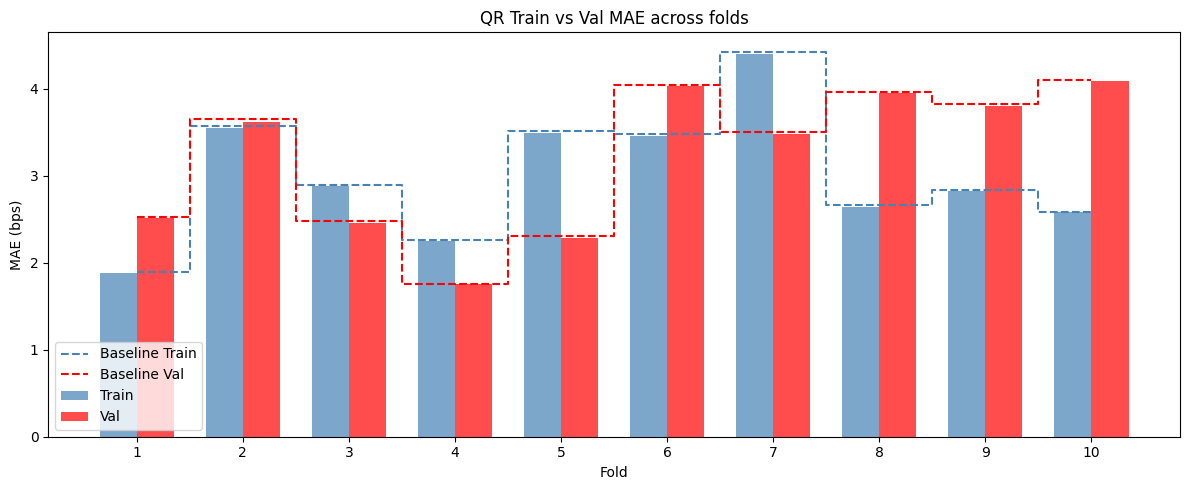

In [472]:
fig, ax = plt.subplots(figsize=(12, 5))
folds = np.arange(1, len(qr_results['val_scores']) + 1)
width = 0.35

ax.bar(folds - width/2, qr_results['train_scores'], width=width, label='Train', alpha=0.7, color='steelblue')
ax.bar(folds + width/2, qr_results['val_scores'], width=width, label='Val', alpha=0.7, color='red')

ax.step(folds, baseline_model['train_scores'], where='mid',color='steelblue', lw=1.5, ls='--', label='Baseline Train')
ax.step(folds, baseline_model['val_scores'], where='mid',color='red', lw=1.5, ls='--', label='Baseline Val')

ax.set_xlabel('Fold')
ax.set_ylabel('MAE (bps)')
ax.set_title('QR Train vs Val MAE across folds')
ax.set_xticks(folds)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Question 1 - Does this problem exist in the simplified linear model? 

qr_results = results_linear_obi_by_alpha[0]
qr_results['val_scores'][2]
qr_results['train_scores'][2]

qr_results['val_scores'][3]
qr_results['train_scores'][3]

np.float64(2.4626067731927805)

np.float64(2.8829321659348057)

np.float64(1.7508994629553867)

np.float64(2.2503159740651655)

Looks like this problem also exists in the linear model, so it's to do with: 
1. Relationship between OBI and forward returns 
2. Split of the data 

In [490]:
from data_visualisation import plot_rolling_correlation, plot_train_val_distributions, plot_train_val_scatter, plot_rolling_spearman, plot_train_val_scores

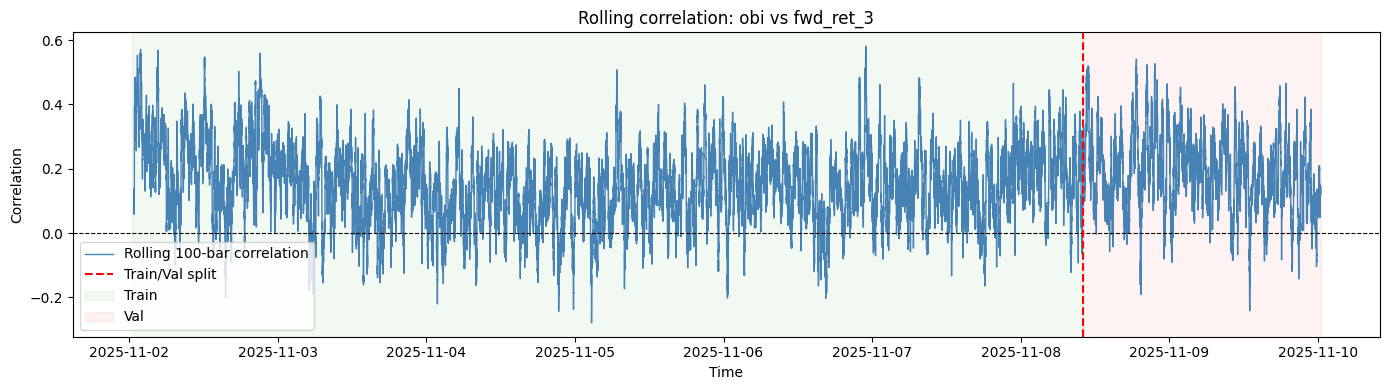

In [416]:
plot_rolling_correlation(df = train_df, feature = 'obi', target = 'fwd_ret_3', train_idx = fold_train, val_idx = fold_test, window = 100)

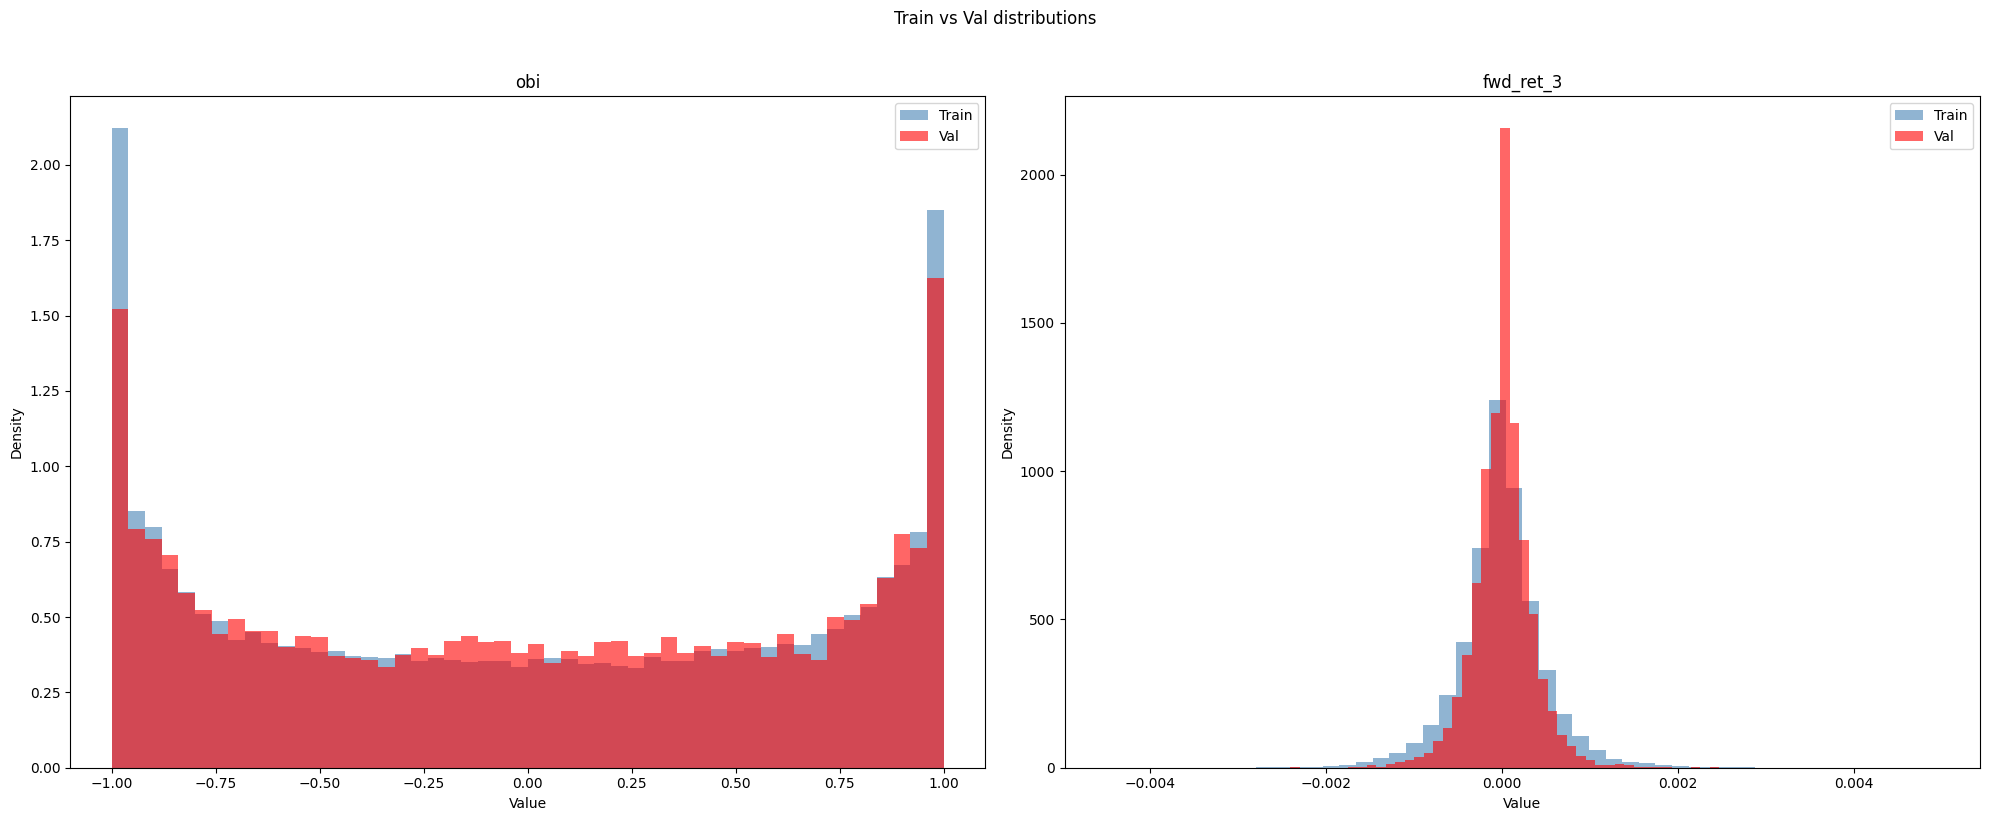

In [417]:
plot_train_val_distributions(train_df, ['obi'], 'fwd_ret_3', fold_train, fold_test)

In [383]:
import seaborn as sns
def plot_train_val_scatter(df, feature, target, train_idx, val_idx, bp_conversion=10000):
    train, val = df.iloc[train_idx], df.iloc[val_idx]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for data, color, label in [(train, 'steelblue', 'Train'), (val, 'red', 'Val')]:
        slope, intercept = np.polyfit(data[feature], data[target]*bp_conversion, 1)
        
        sns.regplot(x=data[feature], y=data[target]*bp_conversion, 
                    ax=ax, scatter=False, color=color,
                    line_kws={'lw': 2, 'label': f'{label} (slope={slope:.3f} bps)'})
    
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'{target} (bps)')
    ax.set_title(f'{feature} vs {target}')
    ax.legend()
    plt.tight_layout()
    plt.show()

/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_31464/822940874.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


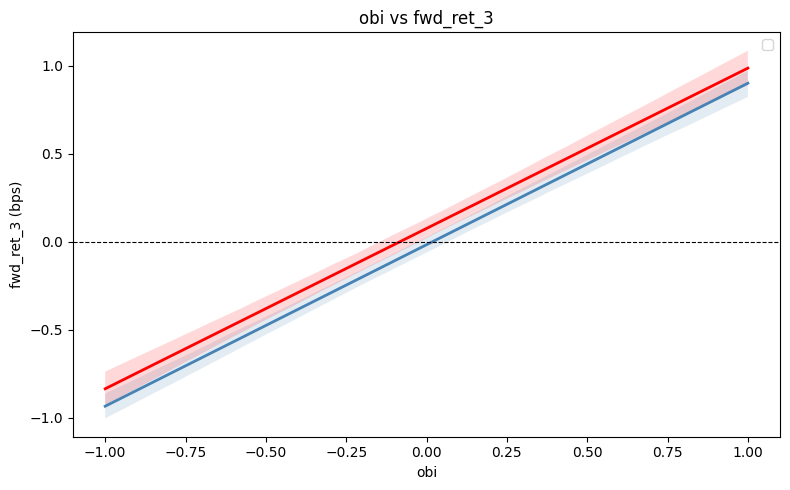

In [418]:
plot_train_val_scatter(train_df, 'obi','fwd_ret_3', fold_train, fold_test)

In [385]:
def plot_train_val_median(df, feature, target, train_idx, val_idx, n_bins=20, bp_conversion=10000):
    train, val = df.iloc[train_idx], df.iloc[val_idx]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for data, color, label in [(train, 'steelblue', 'Train'), (val, 'red', 'Val')]:
        data = data.copy()
        data['bin'] = pd.cut(data[feature], bins=n_bins)
        binned = data.groupby('bin')[target].median() * bp_conversion
        bin_centers = [interval.mid for interval in binned.index]
        
        ax.plot(bin_centers, binned.values, color=color, lw=2, marker='o', ms=4, label=label)
    
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'median {target} (bps)')
    ax.set_title(f'Median {target} by {feature} bin — Train vs Val')
    ax.legend()
    plt.tight_layout()
    plt.show()

/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_31464/186823069.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[target].median() * bp_conversion
/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_31464/186823069.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[target].median() * bp_conversion


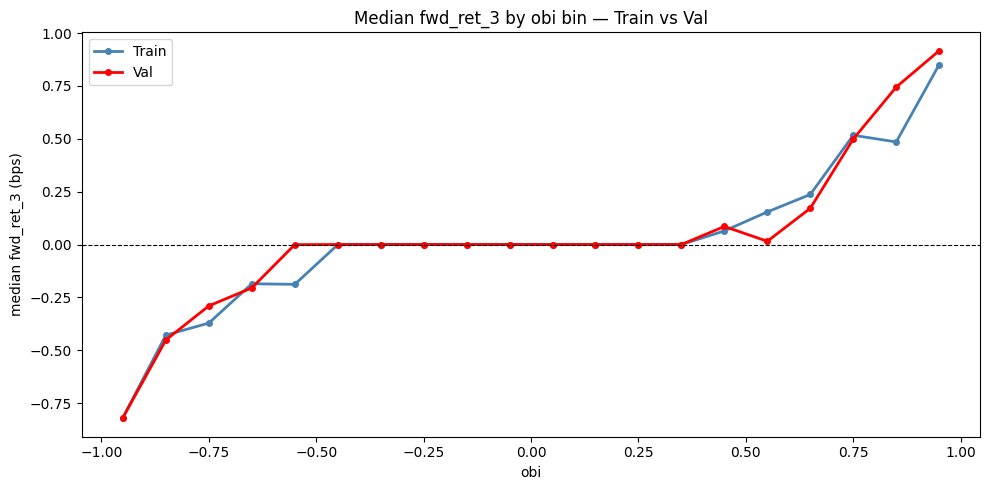

In [419]:
plot_train_val_median(train_df, 'obi','fwd_ret_3', fold_train, fold_test)

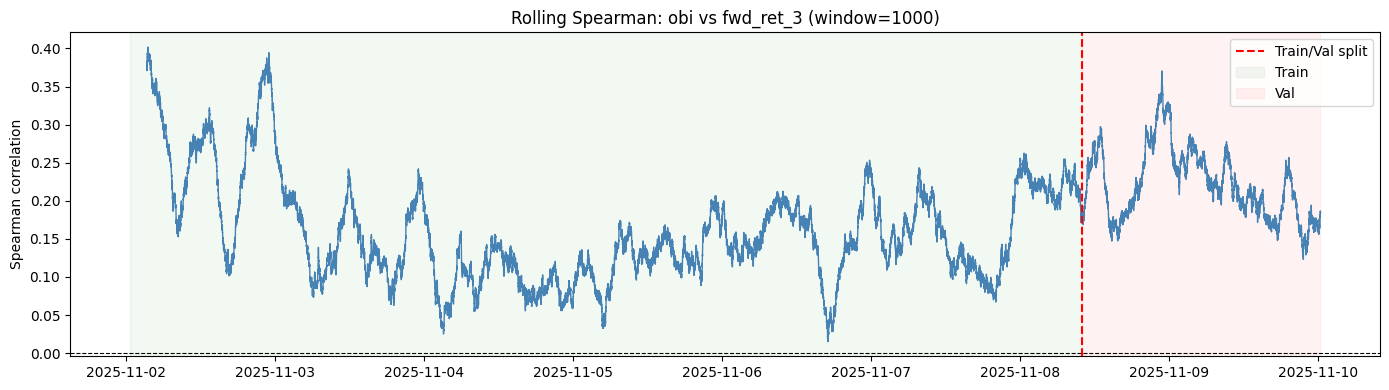

In [422]:
plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', fold_train, fold_test, window = 1000)

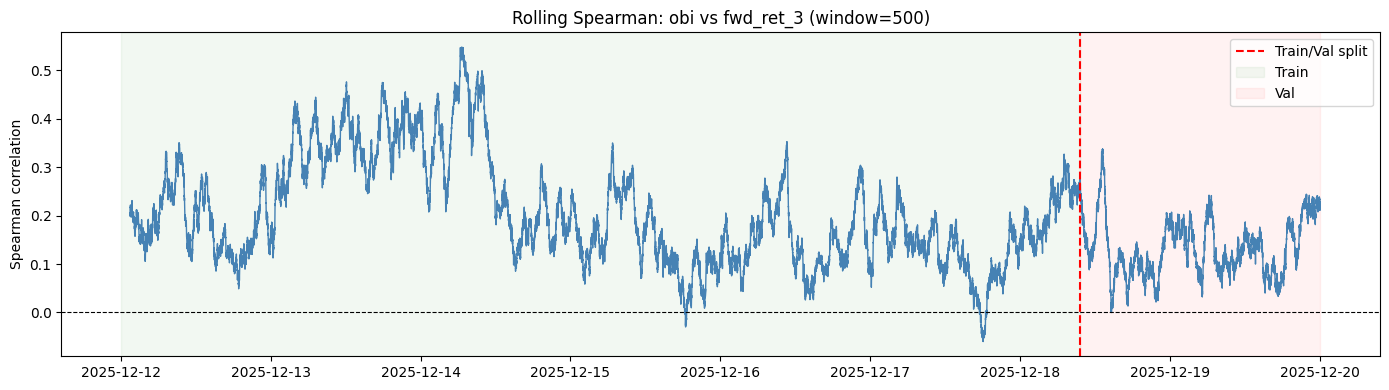

In [424]:
plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', tss[9][0], tss[9][1])

Hard to visually tell - perhaps fold 10 is the really most instructive - see clear visual evidence of some kind of regime change. 

Conclusions 
- Performance across folds is just frankly all over the place, and highly inconsistent 
- Train << test, often the test will underperform BADLY, even worse than a random guess 
- Where test << train, sometimes both are much better than baseline 
- Where test ~ train, i.e. basically nothing has been learned about the data, both perform almost worse than baseline 

## Decision Tree - OBI only 

<BarContainer object of 10 artists>

<BarContainer object of 10 artists>

Text(0.5, 0, 'Fold')

Text(0, 0.5, 'MAE (bps)')

Text(0.5, 1.0, 'QR Train vs Val MAE across folds')

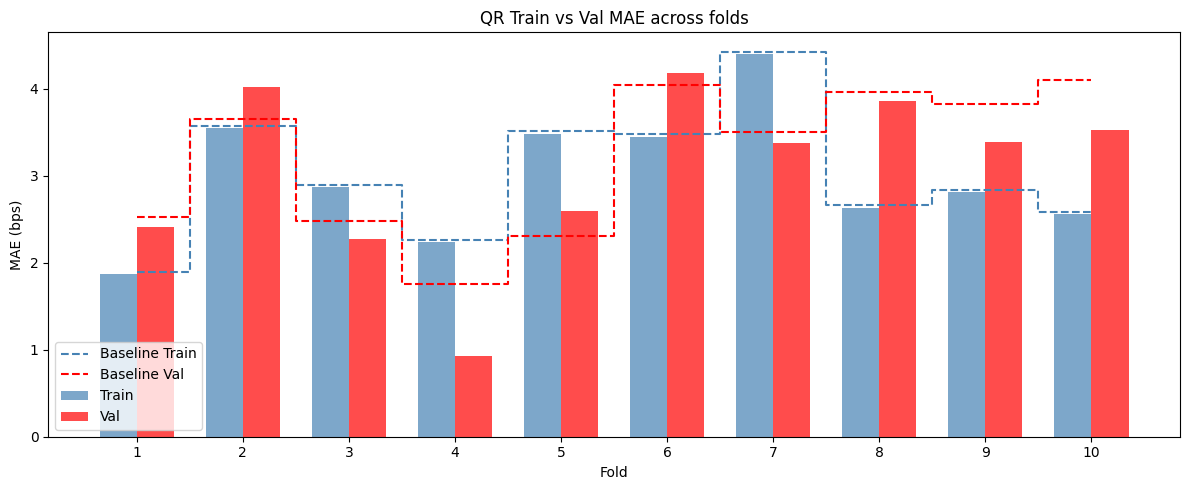

In [470]:
fig, ax = plt.subplots(figsize=(12, 5))
folds = np.arange(1, len(results_nonlinear_obi_early_stopping['val_scores']) + 1)
width = 0.35

ax.bar(folds - width/2, results_nonlinear_obi_early_stopping['train_scores'], width=width, label='Train', alpha=0.7, color='steelblue')
ax.bar(folds + width/2, results_nonlinear_obi_early_stopping['val_scores'], width=width, label='Val', alpha=0.7, color='red')
# step plot gives a per-fold horizontal line that changes each fold
#ax.axhline(BASELINE_PERFORMANCE, color='black', lw=1.5, ls='--', label='Baseline')
ax.step(folds, baseline_model['train_scores'], where='mid',color='steelblue', lw=1.5, ls='--', label='Baseline Train')
ax.step(folds, baseline_model['val_scores'], where='mid',color='red', lw=1.5, ls='--', label='Baseline Val')

ax.set_xlabel('Fold')
ax.set_ylabel('MAE (bps)')
ax.set_title('QR Train vs Val MAE across folds')
ax.set_xticks(folds)
ax.legend()
plt.tight_layout()
plt.show()

Note this is very similar to the picture we saw earlier with a linear QR model with OBI only. 

<BarContainer object of 10 artists>

<BarContainer object of 10 artists>

Text(0.5, 0, 'Fold')

Text(0, 0.5, 'MAE (bps)')

Text(0.5, 1.0, 'QR Train vs Val MAE across folds')

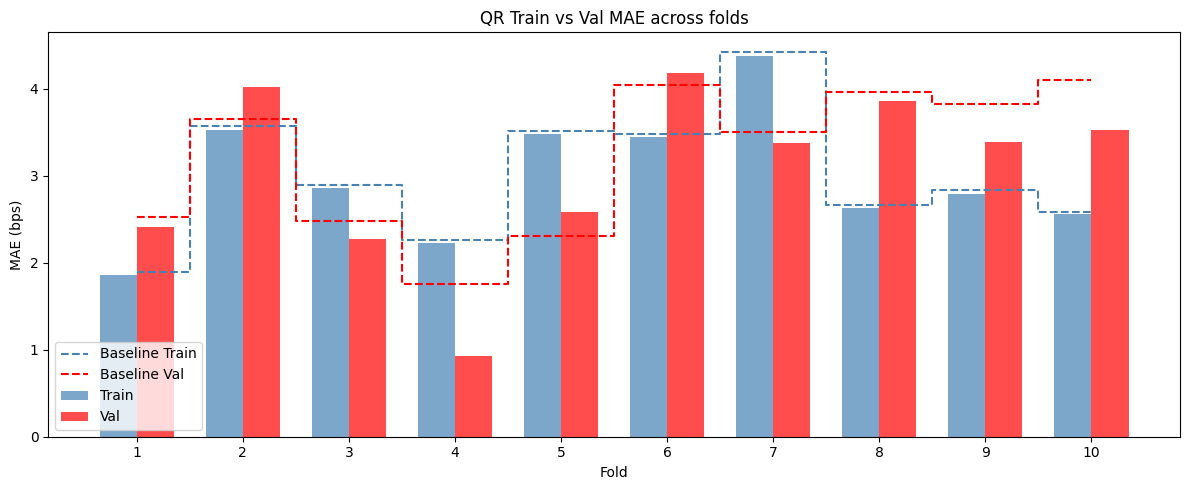

In [471]:
fig, ax = plt.subplots(figsize=(12, 5))
folds = np.arange(1, len(results['val_scores']) + 1)
width = 0.35

ax.bar(folds - width/2, results['train_scores'], width=width, label='Train', alpha=0.7, color='steelblue')
ax.bar(folds + width/2, results['val_scores'], width=width, label='Val', alpha=0.7, color='red')

#ax.axhline(BASELINE_PERFORMANCE, color='black', lw=1.5, ls='--', label='Baseline')

# step plot gives a per-fold horizontal line that changes each fold
ax.step(folds, baseline_model['train_scores'], where='mid',color='steelblue', lw=1.5, ls='--', label='Baseline Train')
ax.step(folds, baseline_model['val_scores'], where='mid',color='red', lw=1.5, ls='--', label='Baseline Val')

ax.set_xlabel('Fold')
ax.set_ylabel('MAE (bps)')
ax.set_title('QR Train vs Val MAE across folds')
ax.set_xticks(folds)
ax.legend()
plt.tight_layout()
plt.show()

A lot of variability across folds, which suggests a kind of time instability relatioship. 

# Debugging steps 
- Fold split is wrong? 
- Add conditional/interaction terms to OBI e.g. for time of day effects/volatility regimes 
- How predictive are my features in the first place? 

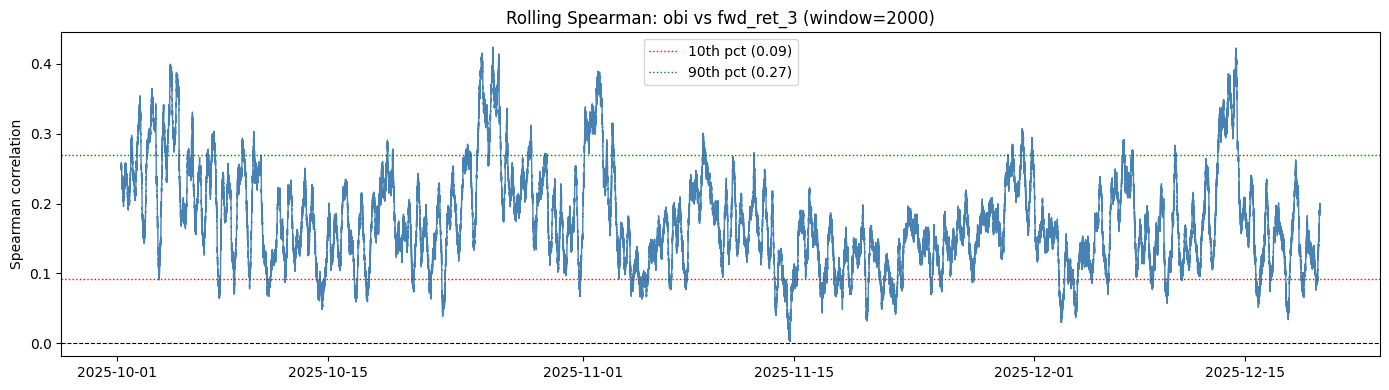

In [452]:
#possibility 1 - fold split is wrong

plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', window = 2000)

# What is our original problem here? Let's refocus back to our original problem - WHY is training data << test data error? Furthermore, is this necessarily a problem? 

- By focusing on just ONE fold, we couldn't it was because of difference in univariate data distributions 
- It is also difficult to SEE from the plots whether this is due to a difference in relationship 

Is this a problem? 

Would prefer behaviour across the folds to be similar, so we can take averages comfortably without fretting that our results are poor. It is also just a really weird result, and makes us distrust our averaging, particularly since the times when we significantly "beat" the baseline is these pathological cases. Let us REALLY continue our drilldown. 

In [481]:
from train import train_test_split
tss= train_test_split(data_length = len(train_df), num_splits = 10, split_ratio = 0.8)
fold_train, fold_test = tss[4]
fold_train_df = train_df.iloc[fold_train]
fold_test_df = train_df.iloc[fold_test]

In [ ]:
# Reason 1 - Relationship changes over time, between periods 

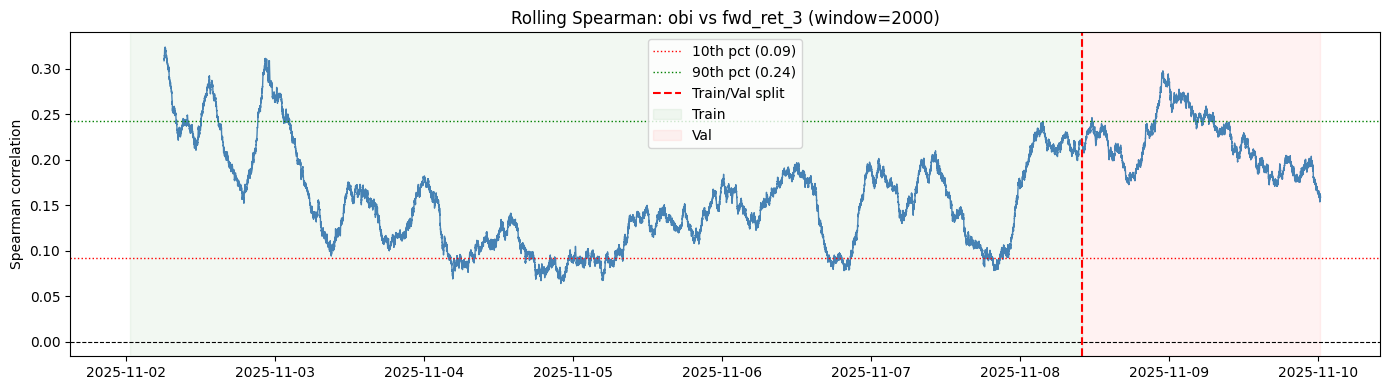

In [ ]:
plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', train_idx = fold_train, val_idx = fold_test, window = 2000)

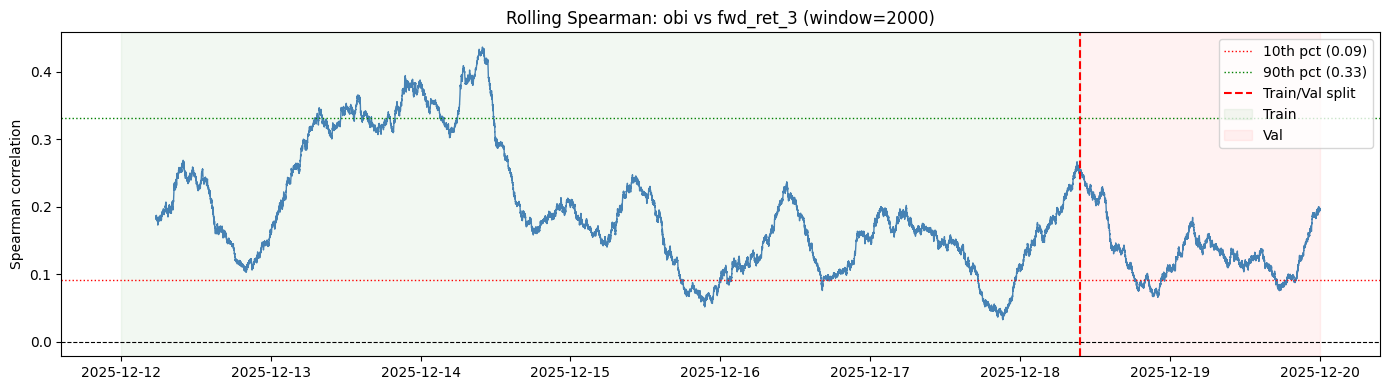

In [487]:
#Compare this to a case where there is overfitting. 

plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', train_idx = tss[9][0], val_idx = tss[9][1], window = 2000)

It is a plausible hypothesis that the reason for the discrepancy in performance between folds (either outperforms or underperforms testing error) is that the relationship changes over time. 

In [ ]:
#Reason 2 - Perhaps the folds are too small, hence an inflated variance 
len(fold_test)
#Unlikely, especially since we also tested on the folds. When would there be an easier relationship?? 

13818

In [ ]:
#our data splits are not right - validation data somehow captures "easier" cases, e.g. a subset of some kind. And in some other cases, there is poor generalisation ability to the validation fold - maybe we captured some "hard" cases.

In [ ]:
#Reason 3 - Maybe we can split cleanly based on the DAY? 

In [493]:
params= {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
    'max_depth': 3,
    'learning_rate': 0.05, #decrease the learning rate 
    'n_estimators': 100,
    'subsample': 0.75,
    'early_stopping_rounds': 20,
    'n_estimators': 200,
}

results = walk_forward_validate(train_df, features = FEAS_LIST, model_kwargs=params, target = TARGET, cv_kwargs = {'num_splits': 10}, cv = 'split_day')

  0%|          | 0/10 [00:00<?, ?it/s]

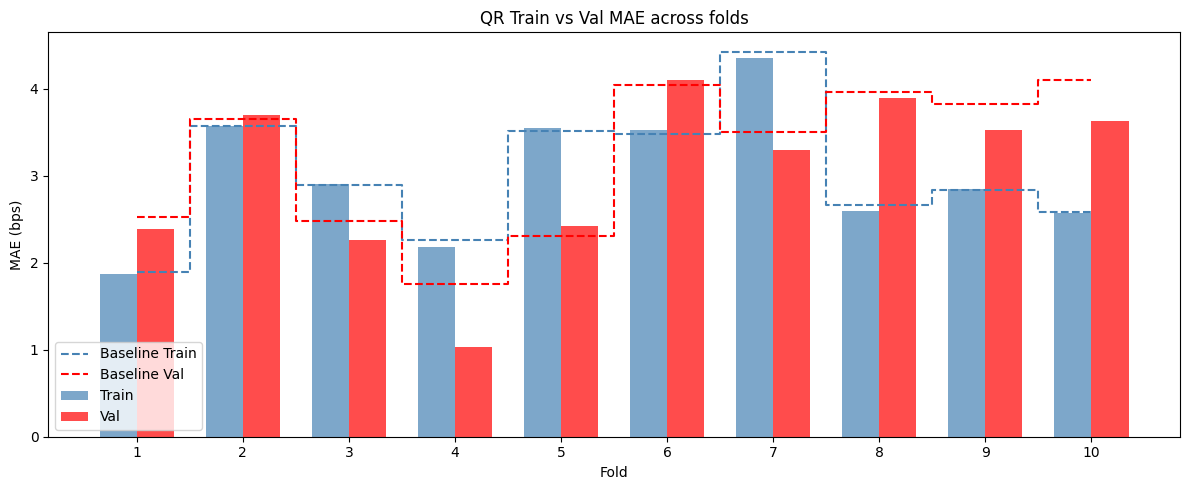

In [494]:
plot_train_val_scores(results = results, baseline_model = baseline_model)

Note that splitting by DAY does not help our situation in this case.

In [495]:
# Simplest reason - why does this result hold for even the dumbest BASELINE prediction? 
#look at proportion with MAE like close to zero? 
from data_visualisation import plot_rolling_mae

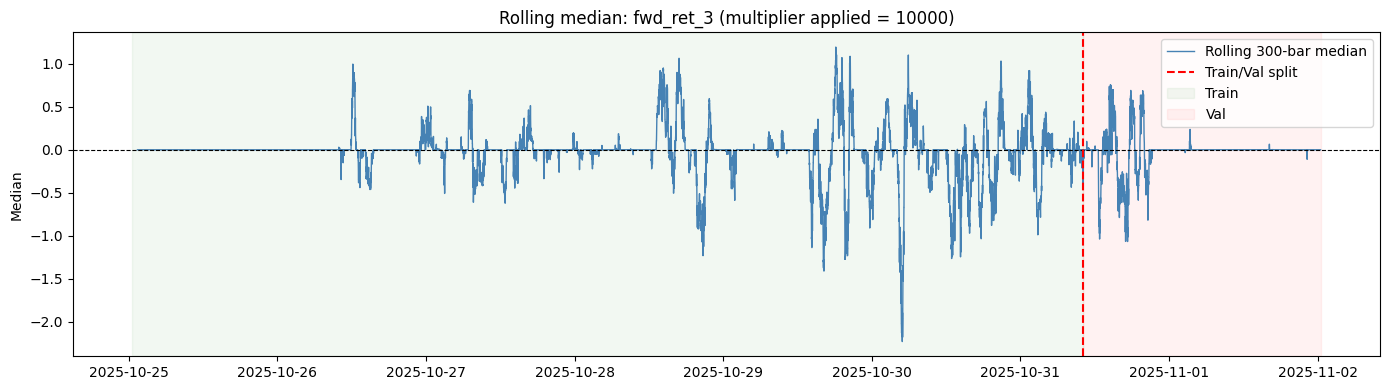

In [515]:
plot_rolling_mae(train_df, target = 'fwd_ret_3', train_idx = tss[3][0], val_idx = tss[3][1], window = 300, multiplier = BASIS_POINTS_CONVERSION)

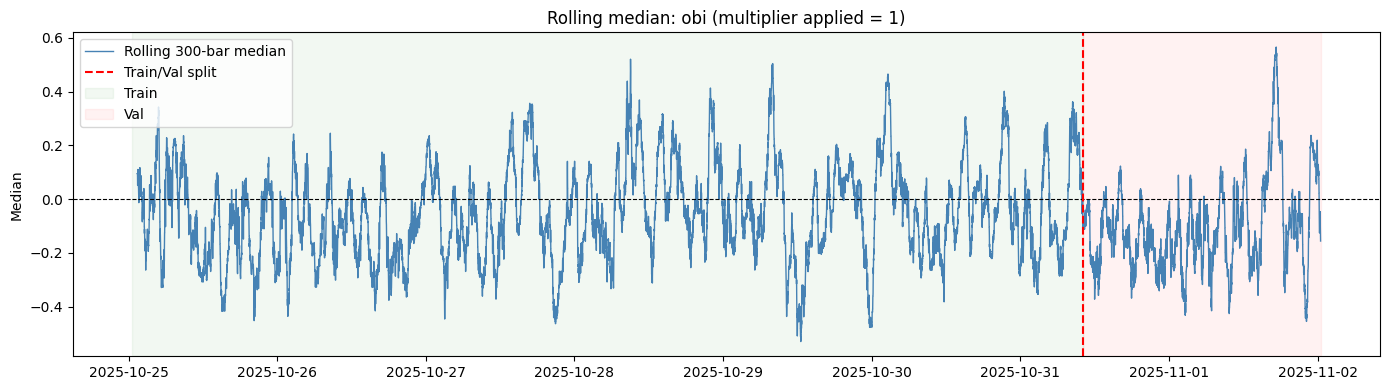

In [516]:
plot_rolling_mae(train_df, target = 'obi', train_idx = tss[3][0], val_idx = tss[3][1], window = 300)

In [518]:
def plot_predictions_vs_time(model, train, val, features, target, bp_conversion=10000):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    
    for ax, data, label, color in [
        (axes[0], train, 'Train', 'steelblue'),
        (axes[1], val,   'Val',   'red')
    ]:
        y_pred = model.predict(data[features])
        
        ax.plot(data.index, data[target] * bp_conversion, 
                color='black', lw=0.5, alpha=0.5, label='Actual')
        ax.plot(data.index, y_pred * bp_conversion, 
                color=color, lw=1, alpha=0.8, label='Predicted')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title(f'{label}')
        ax.set_ylabel(f'{target} (bps)')
        ax.legend()
    
    plt.suptitle('Actual vs Predicted over time')
    plt.tight_layout()
    plt.show()

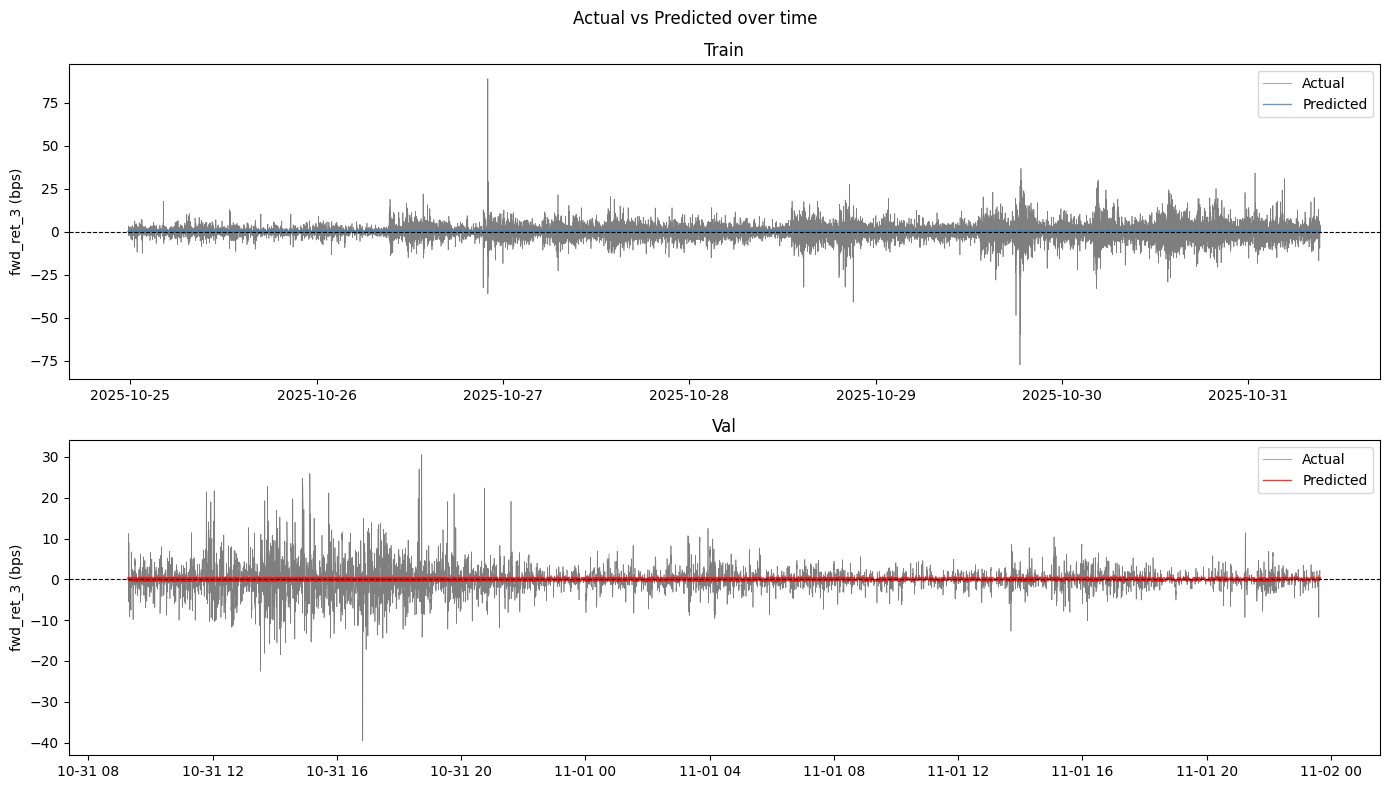

In [520]:
# usage
train, val = df.iloc[tss[3][0]], df.iloc[tss[3][1]]
plot_predictions_vs_time(qr_results['models'][3], train, val, features=['obi'], target='fwd_ret_3')

So the mechnical reason is because in these training sets, there are just more days with like MAE that is functionally close to zero! 

How does this relate to QR? 
- The problem is that in these situations, the model learned almost nothing so it was basically LIKE a baseline model, in some sense. 

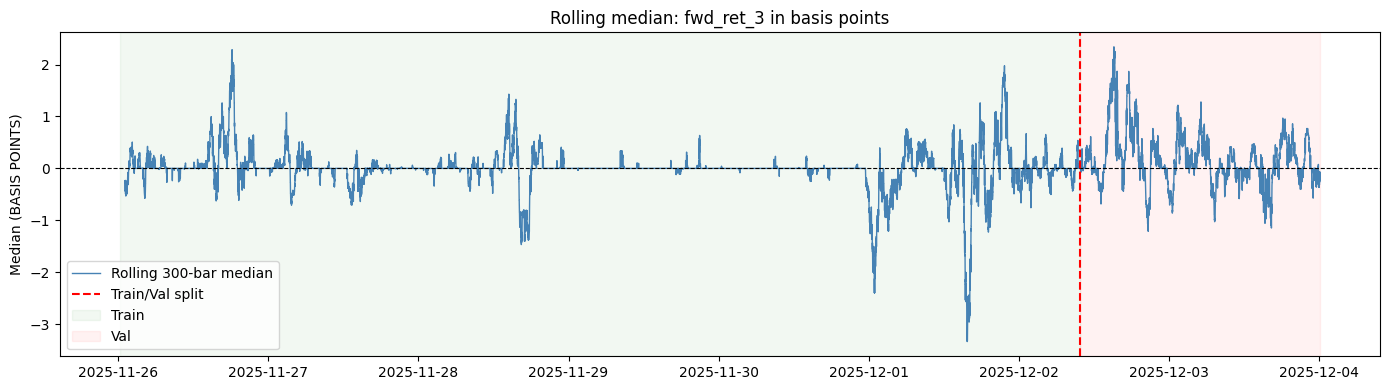

In [512]:
plot_rolling_mae(train_df, target = 'fwd_ret_3', train_idx = tss[7][0], val_idx = tss[7][1], window = 300)

In [ ]:
#Question - How much are our models actually LEARNING each period? 

#Plot the difference between baseline performance vs. training score performance in each fold for each of the models 

Ok, so we are dealing with a case where we don't really .. LEARN anything from the data at hand. And then due to randomness/sampling error of the splits, sometimes the dataset is just somewhat..."easier" than others. 

What my next steps are?
1. Are we even optimising/trying to TRADE for the right objective function? We saw the plot that MAE does not even **MOVE** for OBI larger than zero. 
2. How can we translate this into a viable trading strategy? 